# Notebook 4 (POC) — Lake Kivu Limnic Eruption Dense CO₂ Cloud (paper-grounded single run)

This notebook implements a **single-run proof of concept** aligned to the mathematical specification in `kivu_limnic_math_spec.md`.

**Key features**
- Instantaneous **circular eruption footprint** (disk) with released CO₂ stacked as a thick near-ground layer.
- **Two-layer surrogate**: ground-hugging dense layer follows terrain; wind acts primarily on a mixed/top layer.
- Paper-grounded hazard additions:
  - Near-ground concentration at height **z** using exponential vertical profile (Eq. 4–5).
  - Fatality probability from concentration and exposure duration using the calibrated error-function model (Eq. 7–9).
  - Optional source-regime Richardson number (Eq. 10–11).

**Outputs**
- `runs/.../metrics_hourly.csv` with hourly plume + exposure + lethality metrics
- snapshot PNGs for sanity checks


In [1]:

# === Imports & paths ===
import os, json, math, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import xy as rc_to_xy
from scipy.special import erf as ERF


import matplotlib.pyplot as plt

np.set_printoptions(edgeitems=3, linewidth=140, suppress=True)
pd.set_option("display.max_colwidth", 200)

PROJECT_ROOT = Path(".").resolve()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
RUNS_DIR = PROJECT_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

STATIC_PATH = PROC_DIR / "static_layers.json"
assert STATIC_PATH.exists(), f"Missing {STATIC_PATH}. Run Notebook 3 to produce it."

static = json.loads(STATIC_PATH.read_text())
print("[INFO] Loaded static layers:", STATIC_PATH)
print("[INFO] Grid CRS:", static["crs"], "| shape:", static["shape"], "| dx/dy:", static["dx_m"], static["dy_m"])


[INFO] Loaded static layers: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\data\processed\static_layers.json
[INFO] Grid CRS: EPSG:32735 | shape: [730, 687] | dx/dy: 250.0 250.0


In [2]:

# === Load rasters & masks ===
def load_raster(path):
    ds = rasterio.open(path)
    arr = ds.read(1)
    return ds, arr

paths = static["paths"]
dem_ds, dem = load_raster(paths["dem"])
pop_ds, pop = load_raster(paths["pop"])
u_ds, u_slope = load_raster(paths["u_slope"])
v_ds, v_slope = load_raster(paths["v_slope"])
ml_ds, mask_lake = load_raster(paths["mask_lake"])
mw_ds, mask_water = load_raster(paths["mask_water"])
mL_ds, mask_land = load_raster(paths["mask_land"])
gt_ds, _ = load_raster(paths["grid_template"])

H, W = dem.shape
dx = float(static["dx_m"]); dy = float(static["dy_m"])
cell_area = dx * dy

print("\n[CHECK] Shapes:", dem.shape, pop.shape, u_slope.shape, v_slope.shape, mask_lake.shape)
print("[CHECK] CRS all equal? ", dem_ds.crs == pop_ds.crs == u_ds.crs == v_ds.crs == ml_ds.crs == gt_ds.crs)
print("[CHECK] Transform equal?", dem_ds.transform == pop_ds.transform == u_ds.transform == v_ds.transform == ml_ds.transform == gt_ds.transform)
print("[CHECK] cell_area (m^2):", cell_area)

dem = dem.astype("float32")
pop = pop.astype("float32")
u_slope = u_slope.astype("float32")
v_slope = v_slope.astype("float32")

source_idx = json.loads(Path(paths["source_index"]).read_text())
src_r, src_c = int(source_idx["row"]), int(source_idx["col"])
src_x, src_y = rc_to_xy(gt_ds.transform, src_r, src_c)

print("[SOURCE] row,col:", (src_r, src_c), "| inside lake?", bool(mask_lake[src_r, src_c] == 1))
print("[SOURCE] x,y (UTM cell center):", (float(src_x), float(src_y)))

def stats(name, arr):
    arr = np.asarray(arr)
    print(f"[STATS] {name}: dtype={arr.dtype}, nan={int(np.isnan(arr).sum())}, inf={int(np.isinf(arr).sum())}, "
          f"min={np.nanmin(arr):.4g}, max={np.nanmax(arr):.4g}")

stats("DEM", dem)
stats("POP", pop)
stats("u_slope", u_slope)
stats("v_slope", v_slope)
print("[MASK] lake pixels:", int(mask_lake.sum()), "water pixels:", int(mask_water.sum()), "land pixels:", int(mask_land.sum()))



[CHECK] Shapes: (730, 687) (730, 687) (730, 687) (730, 687) (730, 687)
[CHECK] CRS all equal?  True
[CHECK] Transform equal? True
[CHECK] cell_area (m^2): 62500.0
[SOURCE] row,col: (316, 361) | inside lake? True
[SOURCE] x,y (UTM cell center): (734625.0, 9777375.0)
[STATS] DEM: dtype=float32, nan=3187, inf=0, min=734, max=4448
[STATS] POP: dtype=float32, nan=0, inf=0, min=0, max=2572
[STATS] u_slope: dtype=float32, nan=6007, inf=0, min=-1, max=1
[STATS] v_slope: dtype=float32, nan=6007, inf=0, min=-1, max=1
[MASK] lake pixels: 41467 water pixels: 50473 land pixels: 451037


## Scenario configuration
Single-run POC. Adjust values and rerun.


In [3]:

# === Scenario config (single run) ===
scenario = {
    # Time
    "duration_h": 12,
    "dt_report_h": 10/60,
    "dt_internal_s": 120,   # physics substep; reporting remains hourly

    # CO2 inventory (upper-limit) and release
    "co2_inventory_upper_m3_stp": 3.0e11,  # 300 km^3 at STP
    "release_fraction": 1.0,
    "release_duration_h": 1.0,             # used for Ri regime check (source flux)

    # Eruption footprint (disk)
    "eruption_radius_m": 3000.0,
    "constrain_disk_to_lake": True,

    # Wind (affects top layer; also enhances entrainment)
    "wind_speed_mps": 0.5,
    "wind_dir_deg_from": 0.0,

    # Terrain-following layer (base)
    "slope_speed_mode": "tanh",
    "slope_tanh_beta": 0.6,
    "slope_vmax_mps": float(static["params"]["slope_vmax_mps"]),

    # Diffusion
    "K_base_m2ps": 2.0,
    "K_top_m2ps": 20.0,

    # Coupling and removal
    "entrain_rate_1ps": 2.0e-5,
    "entrain_wind_gain": 1.0,
    "strip_coeff_1ps_per_mps": 2.0e-4,
    "base_background_loss_1ps": 2.0e-6,

    # Concentration mapping parameters (paper-grounded)
    "S1": 0.5,
    "rho_air": 1.20,
    "rho_co2": 1.84,
    "c_background_ppm": 420.0,
    "z_human_m": 1.5,

    # Effective cloud depth cap/min (to infer h, rho from surrogate H_total)
    "h_cap_m": 50.0,
    "h_min_m": 0.5,

    # Lethality model parameters (Folch et al. 2017 calibrated)
    "fatal_a0": 5.056, "fatal_b0": 17.885, "fatal_c0": 0.357,
    "fatal_a1": 0.662, "fatal_b1": 2.421,  "fatal_c1": 0.354,

    # Exposure accumulation substep (minutes)
    "exposure_substep_min": 5,
}

scenario["released_volume_STP_m3"] = scenario["co2_inventory_upper_m3_stp"] * scenario["release_fraction"]
print("[SCENARIO]", json.dumps(scenario, indent=2))


[SCENARIO] {
  "duration_h": 12,
  "dt_report_h": 0.16666666666666666,
  "dt_internal_s": 120,
  "co2_inventory_upper_m3_stp": 300000000000.0,
  "release_fraction": 1.0,
  "release_duration_h": 1.0,
  "eruption_radius_m": 3000.0,
  "constrain_disk_to_lake": true,
  "wind_speed_mps": 0.5,
  "wind_dir_deg_from": 0.0,
  "slope_speed_mode": "tanh",
  "slope_tanh_beta": 0.6,
  "slope_vmax_mps": 1.0,
  "K_base_m2ps": 2.0,
  "K_top_m2ps": 20.0,
  "entrain_rate_1ps": 2e-05,
  "entrain_wind_gain": 1.0,
  "strip_coeff_1ps_per_mps": 0.0002,
  "base_background_loss_1ps": 2e-06,
  "S1": 0.5,
  "rho_air": 1.2,
  "rho_co2": 1.84,
  "c_background_ppm": 420.0,
  "z_human_m": 1.5,
  "h_cap_m": 50.0,
  "h_min_m": 0.5,
  "fatal_a0": 5.056,
  "fatal_b0": 17.885,
  "fatal_c0": 0.357,
  "fatal_a1": 0.662,
  "fatal_b1": 2.421,
  "fatal_c1": 0.354,
  "exposure_substep_min": 5,
  "released_volume_STP_m3": 300000000000.0
}


In [4]:

# === Wind conversion & CFL check ===
def wind_to_uv(speed_mps, dir_from_deg):
    dir_to = (dir_from_deg + 180.0) % 360.0
    rad = np.deg2rad(dir_to)
    u = speed_mps * np.sin(rad)
    v = speed_mps * np.cos(rad)
    return float(u), float(v)

u_wind, v_wind = wind_to_uv(scenario["wind_speed_mps"], scenario["wind_dir_deg_from"])
wind_mag = float(np.sqrt(u_wind*u_wind + v_wind*v_wind))
print("[WIND] u,v (m/s):", (u_wind, v_wind), "| |wind|:", wind_mag)

u_total_max = float(np.nanmax(np.abs(u_slope))) + abs(u_wind)
v_total_max = float(np.nanmax(np.abs(v_slope))) + abs(v_wind)
dt_cfl = min(0.5*dx/(u_total_max+1e-12), 0.5*dy/(v_total_max+1e-12))
print("[CFL] suggested dt <= ", dt_cfl, "seconds (safety factor 0.5)")
if scenario["dt_internal_s"] > dt_cfl:
    print(f"[WARN] dt_internal_s={scenario['dt_internal_s']} > dt_cfl≈{dt_cfl:.1f}. Lower dt_internal_s if unstable.")
else:
    print("[OK] dt_internal within CFL suggestion.")


[WIND] u,v (m/s): (6.123233995736766e-17, -0.5) | |wind|: 0.5
[CFL] suggested dt <=  83.33333333327778 seconds (safety factor 0.5)
[WARN] dt_internal_s=120 > dt_cfl≈83.3. Lower dt_internal_s if unstable.


In [5]:

# === Regime selection check (Ri) at source ===
def richardson_number(v_wind, q_m3ps, r_m, rho_g, rho_e, g=9.81):
    gprime = g * (rho_g - rho_e) / (rho_e + 1e-12)
    Ri = (1.0 / (v_wind**2 + 1e-12)) * ((gprime * q_m3ps / (r_m + 1e-12)) ** (2.0/3.0))
    return float(Ri), float(gprime)

released = float(scenario["released_volume_STP_m3"])
T = float(scenario["release_duration_h"]*3600.0)
q = released / max(T, 1.0)  # m3/s
Ri, gprime = richardson_number(wind_mag, q, scenario["eruption_radius_m"], scenario["rho_co2"], scenario["rho_air"])

print("[RI] q (m3/s):", f"{q:.3e}", " r (m):", scenario["eruption_radius_m"])
print("[RI] g' (m/s^2):", f"{gprime:.4f}", " Ri:", f"{Ri:.4f}")
if Ri < 0.25:
    print("[RI] Regime suggests PASSIVE dispersion (wind-dominated).")
elif Ri > 1.0:
    print("[RI] Regime suggests DENSE gravity-current dispersion (terrain-following).")
else:
    print("[RI] Intermediate regime; dense model is conservative.")


[RI] q (m3/s): 8.333e+07  r (m): 3000.0
[RI] g' (m/s^2): 5.2320  Ri: 11056.9874
[RI] Regime suggests DENSE gravity-current dispersion (terrain-following).


In [6]:

# === Helper operators ===
def shape_slope_velocity(u, v, mode="raw", vmax=1.0, beta=1.0):
    u = u.astype("float32"); v = v.astype("float32")
    speed = np.sqrt(u*u + v*v)
    if mode == "raw":
        return u, v
    if mode == "tanh":
        s = speed / (vmax + 1e-12)
        new_speed = vmax * np.tanh(beta * s)
        scale = np.where(speed > 0, new_speed / (speed + 1e-12), 0.0).astype("float32")
        return (u * scale).astype("float32"), (v * scale).astype("float32")
    raise ValueError(f"Unknown mode: {mode}")

def advect_upwind(F, u, v, dt, dx, dy):
    F = F.astype("float32")
    u = u.astype("float32"); v = v.astype("float32")

    F_left  = np.pad(F, ((0,0),(1,0)), mode="edge")[:, :-1]
    F_right = np.pad(F, ((0,0),(0,1)), mode="edge")[:, 1:]
    F_up    = np.pad(F, ((1,0),(0,0)), mode="edge")[:-1, :]
    F_down  = np.pad(F, ((0,1),(0,0)), mode="edge")[1:, :]

    dFdx = np.where(u >= 0, (F - F_left) / dx, (F_right - F) / dx)
    dFdy = np.where(v >= 0, (F - F_up) / dy, (F_down - F) / dy)

    return (F - dt * (u * dFdx + v * dFdy)).astype("float32")

def diffuse_laplacian(F, K, dt, dx, dy):
    F = F.astype("float32")

    F_left  = np.pad(F, ((0,0),(1,0)), mode="edge")[:, :-1]
    F_right = np.pad(F, ((0,0),(0,1)), mode="edge")[:, 1:]
    F_up    = np.pad(F, ((1,0),(0,0)), mode="edge")[:-1, :]
    F_down  = np.pad(F, ((0,1),(0,0)), mode="edge")[1:, :]

    lap = (F_left - 2*F + F_right) / (dx*dx) + (F_up - 2*F + F_down) / (dy*dy)
    return (F + (K * dt) * lap).astype("float32")

def apply_loss(F, lam, dt):
    return (F * np.exp(-lam * dt)).astype("float32")

def disk_mask(H, W, center_r, center_c, radius_m, dx, dy, mask_limit=None):
    rr = np.arange(H)[:, None]
    cc = np.arange(W)[None, :]
    dr_m = (rr - center_r) * dy
    dc_m = (cc - center_c) * dx
    disk = ((dr_m**2 + dc_m**2) <= radius_m**2).astype(np.uint8)
    if mask_limit is not None:
        disk = (disk & mask_limit.astype(np.uint8)).astype(np.uint8)
    return disk


In [7]:

# === Paper-grounded vertical profile + ppm conversion (Eq 4–5) ===
def infer_h_rho_from_H(H_total, rho_air, rho_co2, h_min=0.5, h_cap=50.0):
    H_total = H_total.astype("float32")
    h_eff = np.clip(H_total, 0.0, h_cap)
    h_eff = np.where(h_eff > 0, np.maximum(h_eff, h_min), 0.0).astype("float32")
    f = np.where(h_eff > 0, np.clip(H_total / (h_eff + 1e-12), 0.0, 1.0), 0.0).astype("float32")
    rho_bar = (rho_air + f * (rho_co2 - rho_air)).astype("float32")
    return h_eff, rho_bar, f

def rho_at_height_z(h_eff, rho_bar, rho_air, S1, z):
    h = np.maximum(h_eff, 1e-6).astype("float32")
    term = (2.0 / (S1 + 1e-12)) * (rho_bar - rho_air)
    expo = np.exp(-(2.0 / (S1 + 1e-12)) * (z / h)).astype("float32")
    rho_z = (rho_air + term * expo).astype("float32")
    rho_z = np.where(h_eff > 0, rho_z, rho_air).astype("float32")
    return rho_z

def ppm_from_rho(rho_z, rho_air, rho_co2, c_background_ppm):
    frac = (rho_z - rho_air) / ((rho_co2 - rho_air) + 1e-12)
    frac = np.clip(frac, 0.0, 1.0).astype("float32")
    ppm = (c_background_ppm + (1e6 - c_background_ppm) * frac).astype("float32")
    return ppm


[ERUPTION] disk_px: 256  disk_area_km2: 16.0


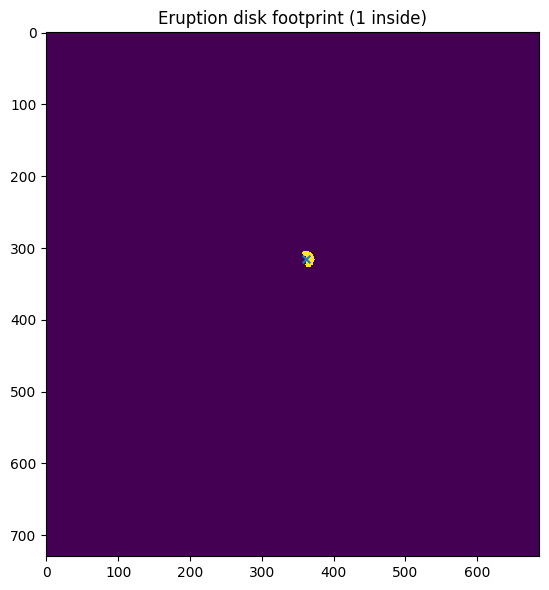

[ERUPTION] released_m3: 3.000e+11 | initial H0 in disk (m): 1.88e+04


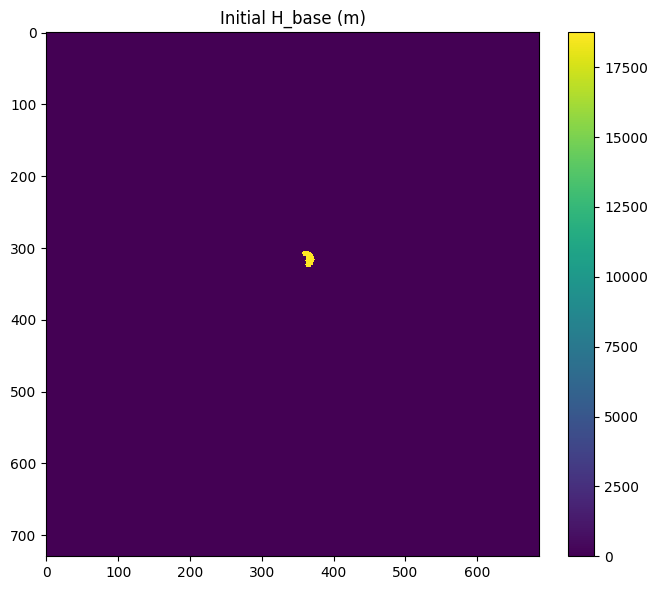

In [8]:

# === Initialize eruption disk and two-layer state ===
limit_mask = mask_lake if scenario["constrain_disk_to_lake"] else None
disk = disk_mask(H, W, src_r, src_c, scenario["eruption_radius_m"], dx, dy, mask_limit=limit_mask)

disk_px = int(disk.sum())
disk_area_m2 = disk_px * cell_area
print("[ERUPTION] disk_px:", disk_px, " disk_area_km2:", disk_area_m2/1e6)

plt.figure(figsize=(7,6))
plt.imshow(disk, interpolation="nearest")
plt.scatter([src_c], [src_r], s=30, marker="x")
plt.title("Eruption disk footprint (1 inside)")
plt.tight_layout()
plt.show()

assert disk_px > 0, "Disk footprint empty; increase radius or check lake mask."

released_m3 = float(scenario["released_volume_STP_m3"])
H0 = released_m3 / (disk_area_m2 + 1e-12)
print("[ERUPTION] released_m3:", f"{released_m3:.3e}", "| initial H0 in disk (m):", f"{H0:.3g}")

H_base = np.zeros((H, W), dtype="float32")
H_top  = np.zeros((H, W), dtype="float32")
H_base[disk == 1] = H0

plt.figure(figsize=(8,6))
plt.imshow(H_base, interpolation="nearest")
plt.title("Initial H_base (m)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


[SLOPE] raw speed pctl: [0. 0. 1. 1. 1.]
[SLOPE] shp speed pctl: [0.         0.         0.53704959 0.53704965 0.53704965]


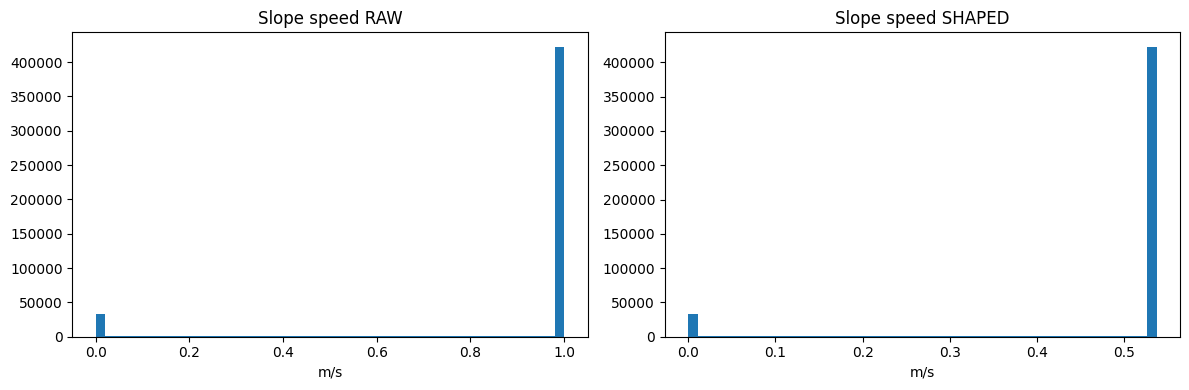

In [9]:

# === Build velocities (base uses terrain; top uses wind) ===
u_s, v_s = shape_slope_velocity(
    u_slope, v_slope,
    mode=scenario["slope_speed_mode"],
    vmax=scenario["slope_vmax_mps"],
    beta=scenario["slope_tanh_beta"]
)

speed_raw = np.sqrt(u_slope*u_slope + v_slope*v_slope)
speed_shp = np.sqrt(u_s*u_s + v_s*v_s)

print("[SLOPE] raw speed pctl:", np.percentile(speed_raw[np.isfinite(speed_raw)], [1,5,50,95,99]))
print("[SLOPE] shp speed pctl:", np.percentile(speed_shp[np.isfinite(speed_shp)], [1,5,50,95,99]))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.hist(speed_raw[np.isfinite(speed_raw)].ravel(), bins=50); plt.title("Slope speed RAW"); plt.xlabel("m/s")
plt.subplot(1,2,2); plt.hist(speed_shp[np.isfinite(speed_shp)].ravel(), bins=50); plt.title("Slope speed SHAPED"); plt.xlabel("m/s")
plt.tight_layout(); plt.show()

u_base, v_base = u_s, v_s
u_top = (u_wind * np.ones((H, W), dtype="float32"))
v_top = (v_wind * np.ones((H, W), dtype="float32"))


In [10]:

# === Metrics helpers ===
THRESH_DANGER_PPM = 50_000.0
THRESH_LETHAL_PPM = 100_000.0

def farthest_dist(mask, src_r, src_c):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return 0.0
    dr = (idx[:,0] - src_r) * dy
    dc = (idx[:,1] - src_c) * dx
    return float(np.sqrt(dr*dr + dc*dc).max())

def weighted_centroid(F, transform):
    Fpos = np.where(np.isfinite(F) & (F > 0), F, 0.0)
    mass = float(Fpos.sum())
    if mass <= 0:
        return (np.nan, np.nan)
    rr = np.arange(F.shape[0])[:, None]
    cc = np.arange(F.shape[1])[None, :]
    r_bar = float((Fpos * rr).sum() / mass)
    c_bar = float((Fpos * cc).sum() / mass)
    x_bar, y_bar = rc_to_xy(transform, r_bar, c_bar)
    return (float(x_bar), float(y_bar))

def compute_metrics(t_hr, H_base, H_top, ppm_z, pop, exposure_min, Pdeath, cum_entr, cum_strip, cum_base_loss):
    H_total = (H_base + H_top).astype("float32")
    vol_base = float(np.nansum(H_base) * cell_area)
    vol_top  = float(np.nansum(H_top) * cell_area)
    vol_tot  = float(np.nansum(H_total) * cell_area)

    max_ppm = float(np.nanmax(ppm_z))
    p95_ppm = float(np.nanpercentile(ppm_z[np.isfinite(ppm_z)], 95)) if np.isfinite(ppm_z).any() else np.nan

    m_danger = (ppm_z >= THRESH_DANGER_PPM)
    m_lethal = (ppm_z >= THRESH_LETHAL_PPM)

    area_danger_km2 = float(m_danger.sum() * cell_area / 1e6)
    area_lethal_km2 = float(m_lethal.sum() * cell_area / 1e6)

    pop_safe = np.where(np.isfinite(pop), pop, 0.0)
    pop_danger = float(np.sum(pop_safe[m_danger]))
    pop_lethal = float(np.sum(pop_safe[m_lethal]))

    exp_fatal = float(np.sum(pop_safe * Pdeath))

    front_danger_m = farthest_dist(m_danger, src_r, src_c)
    front_lethal_m = farthest_dist(m_lethal, src_r, src_c)
    front_base_m = farthest_dist(H_base > 1e-6, src_r, src_c)
    front_top_m = farthest_dist(H_top > 1e-6, src_r, src_c)

    cx_base, cy_base = weighted_centroid(H_base, gt_ds.transform)
    cx_top,  cy_top  = weighted_centroid(H_top, gt_ds.transform)
    cx_tot,  cy_tot  = weighted_centroid(H_total, gt_ds.transform)

    return {
        "time_hr": float(t_hr),

        "vol_base_m3": vol_base,
        "vol_top_m3": vol_top,
        "vol_total_m3": vol_tot,

        "cum_entrained_m3": float(cum_entr),
        "cum_stripped_m3": float(cum_strip),
        "cum_base_loss_m3": float(cum_base_loss),

        "max_ppm_z": max_ppm,
        "p95_ppm_z": p95_ppm,

        "area_danger_km2": area_danger_km2,
        "area_lethal_km2": area_lethal_km2,
        "pop_danger": pop_danger,
        "pop_lethal": pop_lethal,

        "expected_fatalities": exp_fatal,

        "front_danger_m": front_danger_m,
        "front_lethal_m": front_lethal_m,
        "front_base_m": front_base_m,
        "front_top_m": front_top_m,

        "centroid_base_x": cx_base, "centroid_base_y": cy_base,
        "centroid_top_x": cx_top,   "centroid_top_y": cy_top,
        "centroid_total_x": cx_tot, "centroid_total_y": cy_tot,

        "mean_exposure_min": float(np.nanmean(exposure_min)),
        "max_exposure_min": float(np.nanmax(exposure_min)),
        "mean_Pdeath": float(np.nanmean(Pdeath)),
        "max_Pdeath": float(np.nanmax(Pdeath)),

        "wind_u_mps": float(u_wind), "wind_v_mps": float(v_wind), "wind_mag_mps": float(wind_mag),
        "K_base_m2ps": float(scenario["K_base_m2ps"]), "K_top_m2ps": float(scenario["K_top_m2ps"]),
        "entrain_rate_1ps": float(scenario["entrain_rate_1ps"]),
        "strip_coeff_1ps_per_mps": float(scenario["strip_coeff_1ps_per_mps"]),
        "base_background_loss_1ps": float(scenario["base_background_loss_1ps"]),
        "S1": float(scenario["S1"]), "z_human_m": float(scenario["z_human_m"]),
        "h_cap_m": float(scenario["h_cap_m"]),
        "released_volume_STP_m3": float(scenario["released_volume_STP_m3"]),
        "eruption_radius_m": float(scenario["eruption_radius_m"]),
        "Ri_source": float(Ri),
    }


[RUN] Output dir: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\runs\single_run_paper_small
[TIME] n_steps: 360 | report_every: 5 | exposure_every: 2
[PLOTS] plot_every_reports: 6

[SIM] loop start...
[t=   0.0h] ppm_z max=1e+06 | exp max=5.0 min | P max=1.000 | vol_total=2.917e+11 m3
[PLOT] saved snapshot_t000h.png
[t=   1.0h] ppm_z max=1e+06 | exp max=80.0 min | P max=1.000 | vol_total=2.111e+11 m3
[PLOT] saved snapshot_t001h.png
[t=   2.0h] ppm_z max=1e+06 | exp max=155.0 min | P max=1.000 | vol_total=1.925e+11 m3
[PLOT] saved snapshot_t002h.png
[t=   3.0h] ppm_z max=1e+06 | exp max=230.0 min | P max=1.000 | vol_total=1.758e+11 m3
[PLOT] saved snapshot_t003h.png
[t=   4.0h] ppm_z max=1e+06 | exp max=305.0 min | P max=1.000 | vol_total=1.595e+11 m3
[PLOT] saved snapshot_t004h.png
[t=   5.0h] ppm_z max=1e+06 | exp max=380.0 min | P max=1.000 | vol_total=1.390e+11 m3
[PLOT] saved snapshot_t005h.png
[t=   6.0h] ppm_z max=420 | exp max=435.0 min | P max=0.0

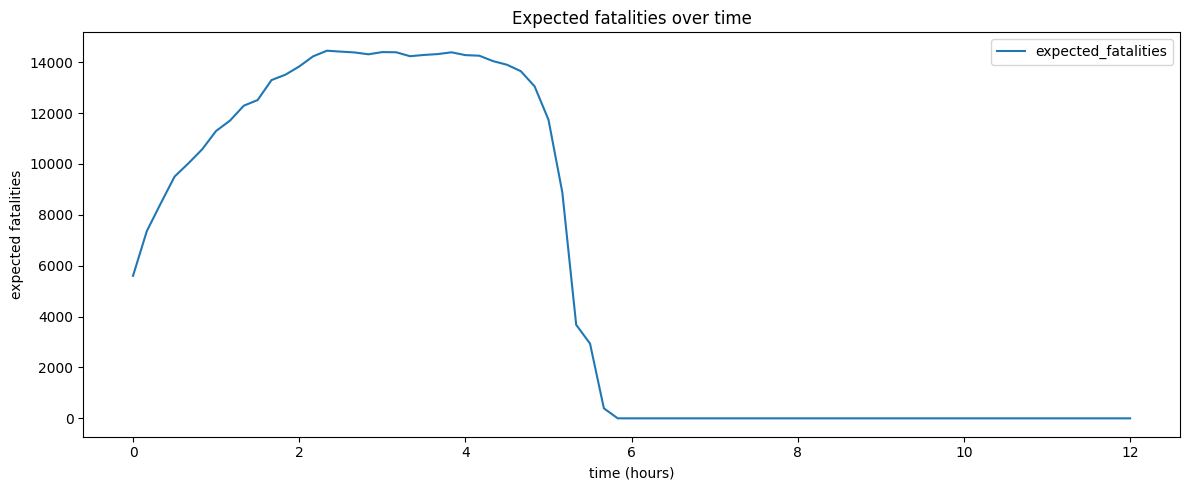


[DONE] Run folder: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\runs\single_run_paper_small


In [11]:

# === Run single simulation (72h) ===
RUN_DIR = RUNS_DIR / f"single_run_paper_small"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("[RUN] Output dir:", RUN_DIR)

(Path(RUN_DIR) / "scenario_config.json").write_text(json.dumps(scenario, indent=2))
(Path(RUN_DIR) / "static_layers.json").write_text(json.dumps(static, indent=2))

duration_s = scenario["duration_h"] * 3600.0
dt_internal = float(scenario["dt_internal_s"])
dt_report_s = scenario["dt_report_h"] * 3600.0

n_steps = int(np.ceil(duration_s / dt_internal))
report_every = max(1, int(round(dt_report_s / dt_internal)))

sub_min = int(scenario["exposure_substep_min"])
sub_s = sub_min * 60.0
sub_every = max(1, int(round(sub_s / dt_internal)))

print("[TIME] n_steps:", n_steps, "| report_every:", report_every, "| exposure_every:", sub_every)

exposure_min = np.zeros((H, W), dtype="float32")
Pdeath = np.zeros((H, W), dtype="float32")

cum_entr = 0.0
cum_strip = 0.0
cum_base_loss = 0.0

metrics_rows = []

PLOT_EVERY_HOURS = 1
plot_every_reports = max(1, int(PLOT_EVERY_HOURS / scenario["dt_report_h"]))
print("[PLOTS] plot_every_reports:", plot_every_reports)

def save_snapshot(t_hr, H_base, H_top, ppm_z, Pdeath, out_png):
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    ax[0,0].imshow(H_base, interpolation="nearest"); ax[0,0].set_title(f"H_base (m) t={t_hr:.1f}h")
    ax[0,1].imshow(H_top, interpolation="nearest");  ax[0,1].set_title(f"H_top (m) t={t_hr:.1f}h")
    im = ax[1,0].imshow(ppm_z, interpolation="nearest"); ax[1,0].set_title(f"CO2 ppm at z={scenario['z_human_m']}m")
    ax[1,1].imshow(Pdeath, interpolation="nearest"); ax[1,1].set_title("P(death)")

    for a in ax.ravel():
        a.scatter([src_c], [src_r], s=30, marker="x")
        a.set_axis_off()
    plt.colorbar(im, ax=ax[1,0], fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(out_png, dpi=140)
    plt.close(fig)

print("\n[SIM] loop start...")
for step in range(n_steps + 1):
    t_s = step * dt_internal
    t_hr = t_s / 3600.0

    # Base transport
    H_base = advect_upwind(H_base, u_base, v_base, dt_internal, dx, dy)
    H_base = diffuse_laplacian(H_base, scenario["K_base_m2ps"], dt_internal, dx, dy)

    # Top transport
    H_top = advect_upwind(H_top, u_top, v_top, dt_internal, dx, dy)
    H_top = diffuse_laplacian(H_top, scenario["K_top_m2ps"], dt_internal, dx, dy)

    # Entrainment base->top (wind-enhanced)
    entrain_eff = scenario["entrain_rate_1ps"] * (1.0 + scenario["entrain_wind_gain"] * wind_mag)
    dE = (entrain_eff * dt_internal) * H_base
    dE = np.minimum(dE, H_base)
    H_base -= dE
    H_top  += dE
    cum_entr += float(np.nansum(dE) * cell_area)

    # Base loss
    base_before = float(np.nansum(H_base) * cell_area)
    H_base = apply_loss(H_base, scenario["base_background_loss_1ps"], dt_internal)
    base_after = float(np.nansum(H_base) * cell_area)
    cum_base_loss += max(0.0, base_before - base_after)

    # Top stripping
    strip_rate = scenario["strip_coeff_1ps_per_mps"] * wind_mag
    top_before = float(np.nansum(H_top) * cell_area)
    H_top = apply_loss(H_top, strip_rate, dt_internal)
    top_after = float(np.nansum(H_top) * cell_area)
    cum_strip += max(0.0, top_before - top_after)

    H_base = np.maximum(H_base, 0).astype("float32")
    H_top  = np.maximum(H_top, 0).astype("float32")

    # Exposure/hazard substep
    if step % sub_every == 0:
        H_total = (H_base + H_top).astype("float32")
        h_eff, rho_bar, f = infer_h_rho_from_H(H_total, scenario["rho_air"], scenario["rho_co2"],
                                               h_min=scenario["h_min_m"], h_cap=scenario["h_cap_m"])
        rho_z = rho_at_height_z(h_eff, rho_bar, scenario["rho_air"], scenario["S1"], scenario["z_human_m"])
        ppm_z = ppm_from_rho(rho_z, scenario["rho_air"], scenario["rho_co2"], scenario["c_background_ppm"])

        EXP_MIN_PPM = 30_000.0
        exposure_min += (ppm_z >= EXP_MIN_PPM).astype("float32") * sub_min

        c_percent = (ppm_z / 1e4).astype("float32")
        d_min = exposure_min.astype("float32")

        mu = scenario["fatal_a0"] + scenario["fatal_b0"] / (1.0 + np.power(d_min, scenario["fatal_c0"]))
        sig = scenario["fatal_a1"] + scenario["fatal_b1"] / (1.0 + np.power(d_min, scenario["fatal_c1"]))
        z = (c_percent - mu) / (np.sqrt(2.0) * (sig + 1e-12))
        Pdeath = (0.5 * (1.0 + ERF(z))).astype("float32")
        Pdeath = np.asarray(Pdeath, dtype="float32")  # ensures ndarray if vectorize fallback is used

        if step % max(1, int(3600/dt_internal)) == 0:
            print(f"[t={t_hr:6.1f}h] ppm_z max={float(np.nanmax(ppm_z)):.3g} | "
                  f"exp max={float(np.nanmax(exposure_min)):.1f} min | "
                  f"P max={float(np.nanmax(Pdeath)):.3f} | "
                  f"vol_total={float(np.nansum(H_total)*cell_area):.3e} m3")

    # Hourly report
    if step % report_every == 0:
        if 'ppm_z' not in locals():
            H_total = (H_base + H_top).astype("float32")
            h_eff, rho_bar, f = infer_h_rho_from_H(H_total, scenario["rho_air"], scenario["rho_co2"],
                                                   h_min=scenario["h_min_m"], h_cap=scenario["h_cap_m"])
            rho_z = rho_at_height_z(h_eff, rho_bar, scenario["rho_air"], scenario["S1"], scenario["z_human_m"])
            ppm_z = ppm_from_rho(rho_z, scenario["rho_air"], scenario["rho_co2"], scenario["c_background_ppm"])

        m = compute_metrics(t_hr, H_base, H_top, ppm_z, pop, exposure_min, Pdeath, cum_entr, cum_strip, cum_base_loss)
        metrics_rows.append(m)

        report_idx = int(round(t_hr / scenario["dt_report_h"]))
        if report_idx % plot_every_reports == 0:
            out_png = RUN_DIR / f"snapshot_t{int(round(t_hr)):03d}h.png"
            save_snapshot(t_hr, H_base, H_top, ppm_z, Pdeath, out_png)
            print("[PLOT] saved", out_png.name)

metrics_df = pd.DataFrame(metrics_rows)
metrics_path = RUN_DIR / "metrics_hourly.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n[WRITE] metrics:", metrics_path, "| rows:", len(metrics_df), "| cols:", metrics_df.shape[1])

plt.figure(figsize=(12,5))
plt.plot(metrics_df["time_hr"], metrics_df["expected_fatalities"], label="expected_fatalities")
plt.xlabel("time (hours)"); plt.ylabel("expected fatalities"); plt.title("Expected fatalities over time")
plt.legend(); plt.tight_layout(); plt.show()

for ds in [dem_ds, pop_ds, u_ds, v_ds, ml_ds, mw_ds, mL_ds, gt_ds]:
    ds.close()

print("\n[DONE] Run folder:", RUN_DIR)


In [12]:

# === Final integrity checks ===
print("[METRICS] columns:", len(metrics_df.columns))
print(metrics_df.head(3))

key_cols = ["vol_total_m3", "max_ppm_z", "expected_fatalities", "pop_lethal", "front_lethal_m", "Ri_source"]
for c in key_cols:
    print(" ", c, "NaN?", bool(metrics_df[c].isna().any()))

summary = {
    "run_dir": str(RUN_DIR),
    "max_expected_fatalities": float(metrics_df["expected_fatalities"].max()),
    "max_pop_lethal": float(metrics_df["pop_lethal"].max()),
    "max_area_lethal_km2": float(metrics_df["area_lethal_km2"].max()),
    "Ri_source": float(metrics_df["Ri_source"].iloc[0]),
}
(Path(RUN_DIR) / "summary.json").write_text(json.dumps(summary, indent=2))
print("[WRITE] summary.json")


[METRICS] columns: 42
    time_hr   vol_base_m3    vol_top_m3  vol_total_m3  cum_entrained_m3  \
0  0.000000  2.906673e+11  1.037905e+09  2.917052e+11      1.050435e+09   
1  0.166667  2.518030e+11  5.610377e+09  2.574134e+11      5.855704e+09   
2  0.333333  2.287403e+11  9.413102e+09  2.381534e+11      1.013779e+10   

   cum_stripped_m3  cum_base_loss_m3  max_ppm_z  p95_ppm_z  area_danger_km2  \
0       12529920.0        69730304.0  1000000.0      420.0          20.3750   
1      245328128.0       388956160.0  1000000.0      420.0          25.5625   
2      724686592.0       673398784.0  1000000.0      420.0          31.1250   

   ...  K_top_m2ps  entrain_rate_1ps  strip_coeff_1ps_per_mps  \
0  ...        20.0           0.00002                   0.0002   
1  ...        20.0           0.00002                   0.0002   
2  ...        20.0           0.00002                   0.0002   

   base_background_loss_1ps   S1  z_human_m  h_cap_m  released_volume_STP_m3  \
0                  

[DIAGNOSTICS]
  peak  expected_fatalities = 1.445e+04 at t=2.3 h
  peak           pop_lethal = 1.442e+04 at t=2.3 h
  peak           pop_danger = 1.492e+04 at t=2.5 h
  peak      area_lethal_km2 = 99.44 at t=4.5 h
  peak      area_danger_km2 = 101.1 at t=4.5 h
  peak            max_ppm_z = 1e+06 at t=0.0 h
  first pop_lethal > 0: 0.0
  first expected_fatalities > 0: 0.0


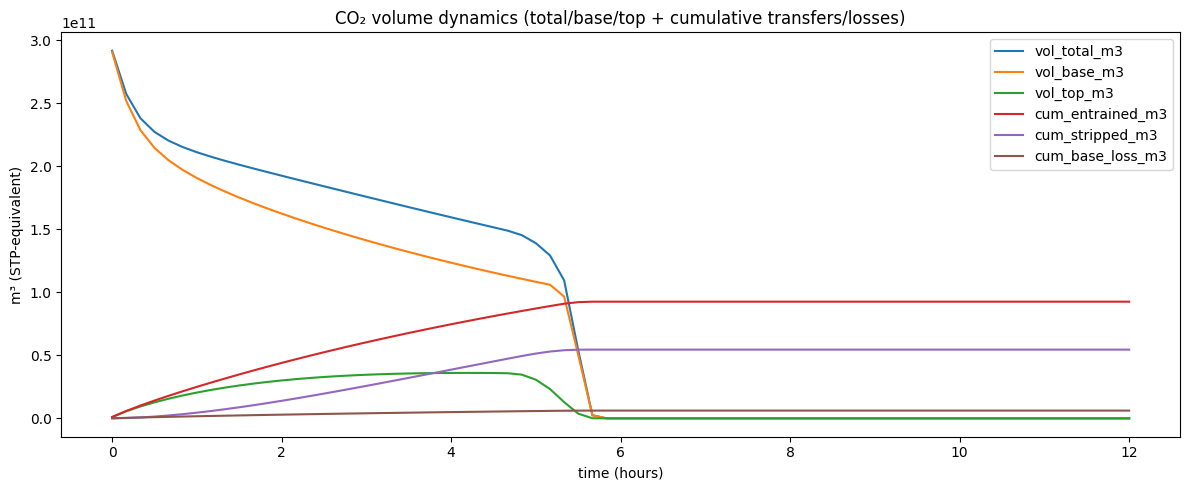

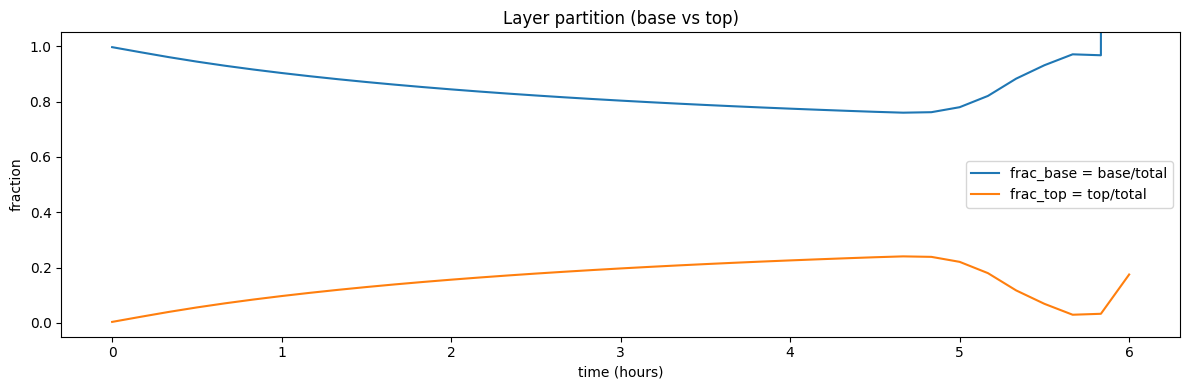

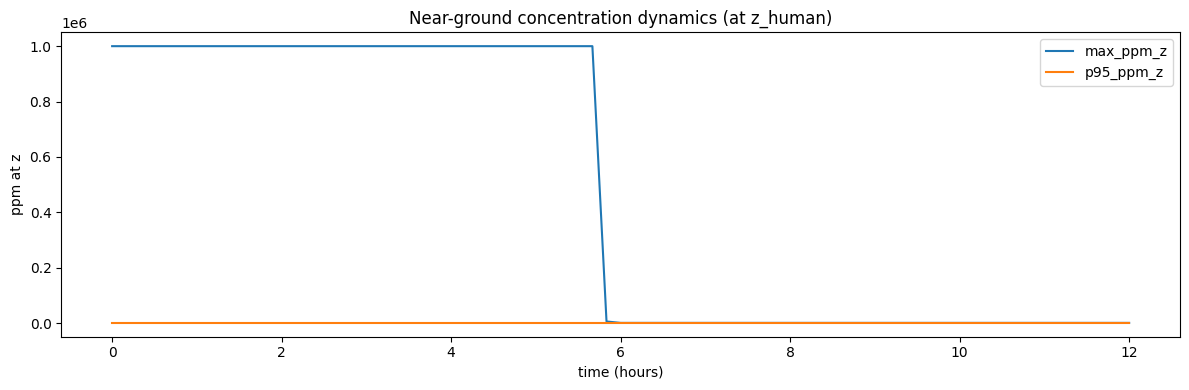

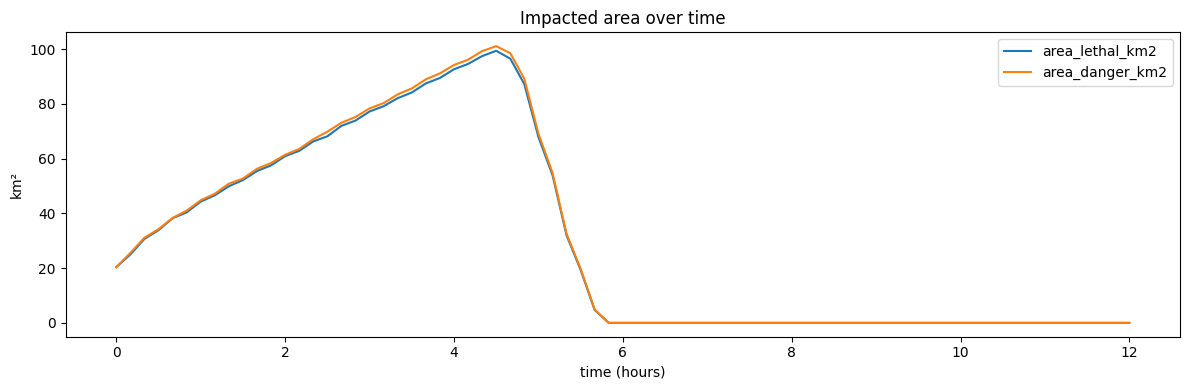

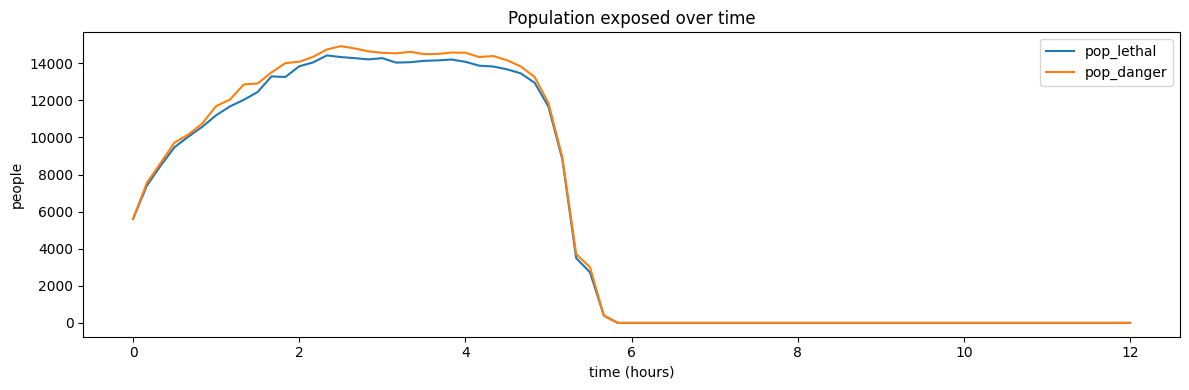

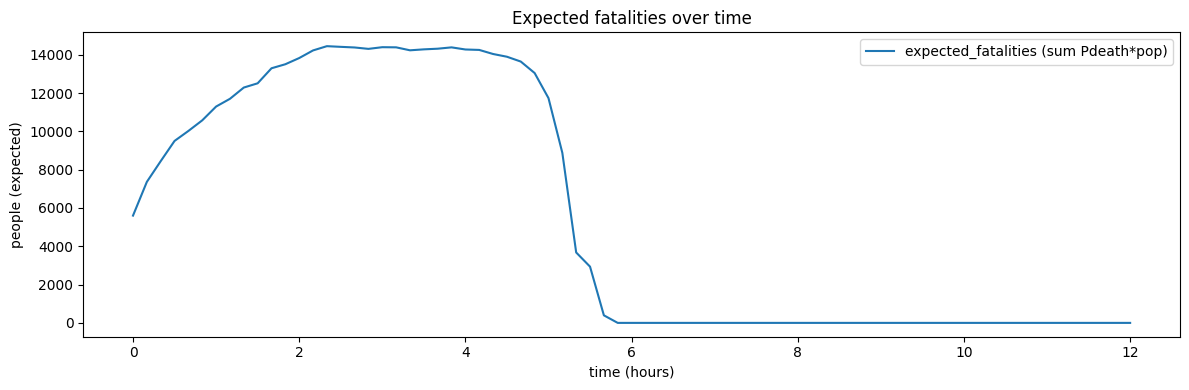

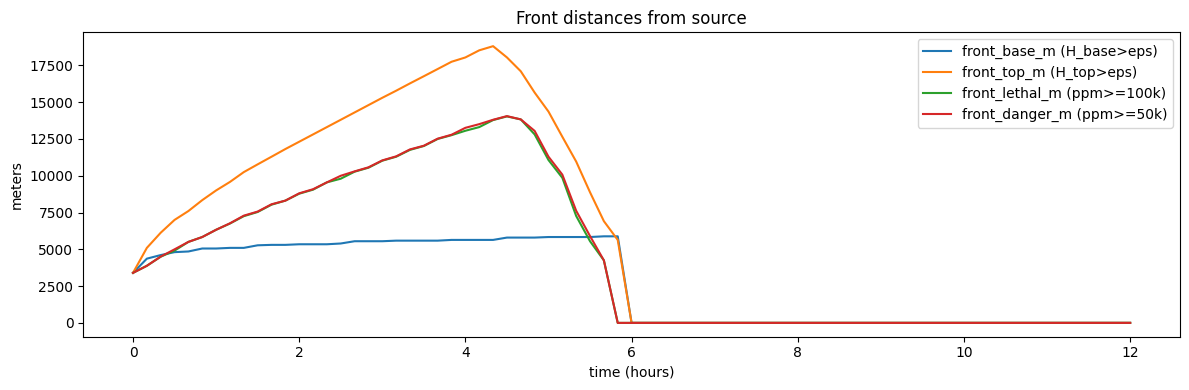

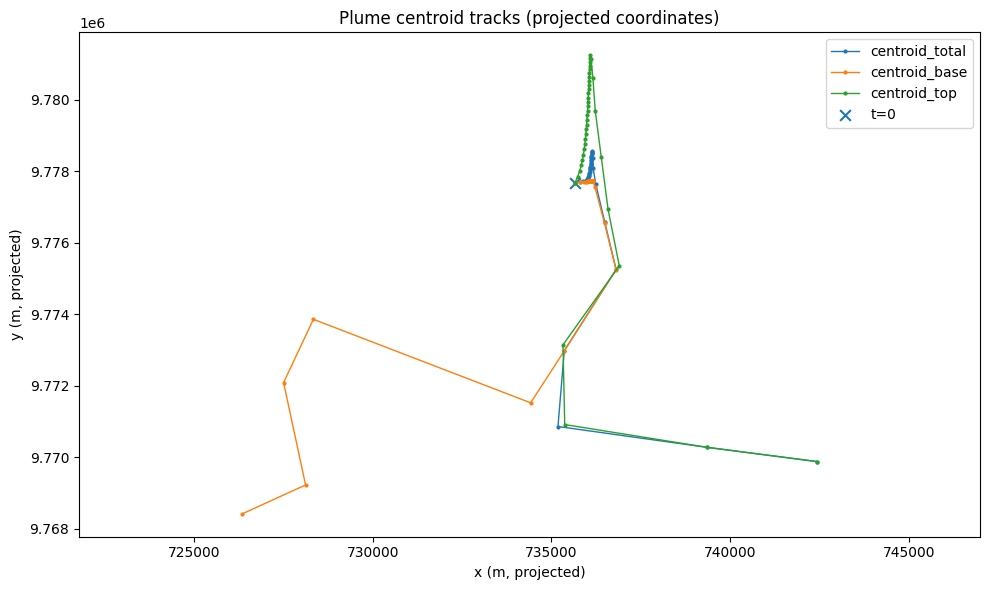

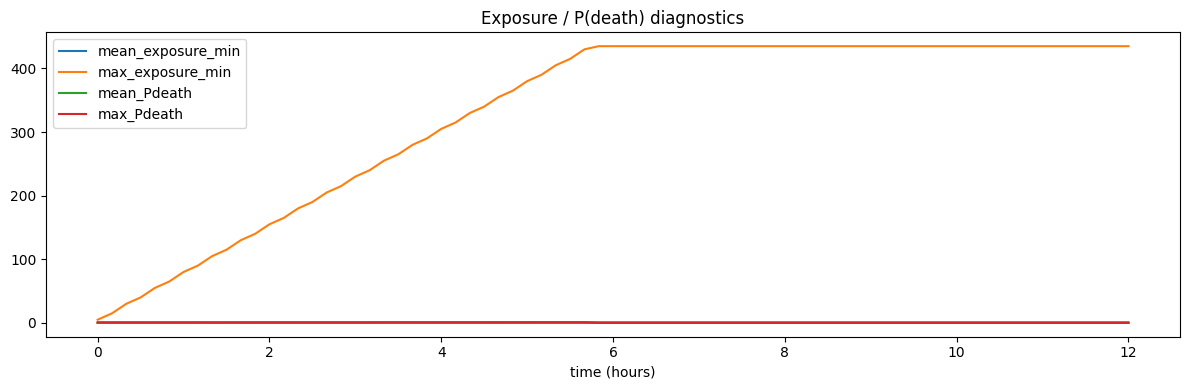

In [13]:
# === Dynamics dashboard for hourly metrics ===
import numpy as np
import matplotlib.pyplot as plt

assert "metrics_df" in globals(), "metrics_df not found. Run the simulation cell first."

df = metrics_df.copy()
t = df["time_hr"].values

def safe_div(a, b):
    b2 = np.where(np.abs(b) < 1e-12, np.nan, b)
    return a / b2

# Derived diagnostics
df["frac_top"] = safe_div(df["vol_top_m3"], df["vol_total_m3"])
df["frac_base"] = safe_div(df["vol_base_m3"], df["vol_total_m3"])
df["lethal_density_per_km2"] = safe_div(df["pop_lethal"], df["area_lethal_km2"])
df["danger_density_per_km2"] = safe_div(df["pop_danger"], df["area_danger_km2"])

print("[DIAGNOSTICS]")
for col in ["expected_fatalities", "pop_lethal", "pop_danger", "area_lethal_km2", "area_danger_km2", "max_ppm_z"]:
    imax = int(df[col].values.argmax())
    print(f"  peak {col:>20s} = {df[col].iloc[imax]:.4g} at t={df['time_hr'].iloc[imax]:.1f} h")

for col in ["pop_lethal", "expected_fatalities"]:
    idx = df.index[df[col] > 0]
    print(f"  first {col} > 0:", (df.loc[idx[0], "time_hr"] if len(idx) else None))

# ---- Plot 1: Volume budget & partition ----
plt.figure(figsize=(12,5))
plt.plot(t, df["vol_total_m3"], label="vol_total_m3")
plt.plot(t, df["vol_base_m3"], label="vol_base_m3")
plt.plot(t, df["vol_top_m3"], label="vol_top_m3")
plt.plot(t, df["cum_entrained_m3"], label="cum_entrained_m3")
plt.plot(t, df["cum_stripped_m3"], label="cum_stripped_m3")
plt.plot(t, df["cum_base_loss_m3"], label="cum_base_loss_m3")
plt.xlabel("time (hours)")
plt.ylabel("m³ (STP-equivalent)")
plt.title("CO₂ volume dynamics (total/base/top + cumulative transfers/losses)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Partition fractions ----
plt.figure(figsize=(12,4))
plt.plot(t, df["frac_base"], label="frac_base = base/total")
plt.plot(t, df["frac_top"], label="frac_top = top/total")
plt.ylim(-0.05, 1.05)
plt.xlabel("time (hours)")
plt.ylabel("fraction")
plt.title("Layer partition (base vs top)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 3: Concentration dynamics ----
plt.figure(figsize=(12,4))
plt.plot(t, df["max_ppm_z"], label="max_ppm_z")
plt.plot(t, df["p95_ppm_z"], label="p95_ppm_z")
plt.xlabel("time (hours)")
plt.ylabel("ppm at z")
plt.title("Near-ground concentration dynamics (at z_human)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 4: Impact areas ----
plt.figure(figsize=(12,4))
plt.plot(t, df["area_lethal_km2"], label="area_lethal_km2")
plt.plot(t, df["area_danger_km2"], label="area_danger_km2")
plt.xlabel("time (hours)")
plt.ylabel("km²")
plt.title("Impacted area over time")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 5: Exposed population ----
plt.figure(figsize=(12,4))
plt.plot(t, df["pop_lethal"], label="pop_lethal")
plt.plot(t, df["pop_danger"], label="pop_danger")
plt.xlabel("time (hours)")
plt.ylabel("people")
plt.title("Population exposed over time")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 6: Expected fatalities ----
plt.figure(figsize=(12,4))
plt.plot(t, df["expected_fatalities"], label="expected_fatalities (sum Pdeath*pop)")
plt.xlabel("time (hours)")
plt.ylabel("people (expected)")
plt.title("Expected fatalities over time")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 7: Front propagation (how far the cloud reaches) ----
plt.figure(figsize=(12,4))
plt.plot(t, df["front_base_m"], label="front_base_m (H_base>eps)")
plt.plot(t, df["front_top_m"], label="front_top_m (H_top>eps)")
plt.plot(t, df["front_lethal_m"], label="front_lethal_m (ppm>=100k)")
plt.plot(t, df["front_danger_m"], label="front_danger_m (ppm>=50k)")
plt.xlabel("time (hours)")
plt.ylabel("meters")
plt.title("Front distances from source")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 8: Plume centroid tracks (map-space) ----
plt.figure(figsize=(10,6))
plt.plot(df["centroid_total_x"], df["centroid_total_y"], marker="o", markersize=2, linewidth=1, label="centroid_total")
plt.plot(df["centroid_base_x"], df["centroid_base_y"], marker="o", markersize=2, linewidth=1, label="centroid_base")
plt.plot(df["centroid_top_x"], df["centroid_top_y"], marker="o", markersize=2, linewidth=1, label="centroid_top")
plt.scatter([df["centroid_total_x"].iloc[0]], [df["centroid_total_y"].iloc[0]], s=60, marker="x", label="t=0")
plt.xlabel("x (m, projected)")
plt.ylabel("y (m, projected)")
plt.title("Plume centroid tracks (projected coordinates)")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

# ---- Optional: exposure metrics if present ----
optional_cols = [c for c in ["mean_exposure_min", "max_exposure_min", "mean_Pdeath", "max_Pdeath"] if c in df.columns]
if optional_cols:
    plt.figure(figsize=(12,4))
    for c in optional_cols:
        plt.plot(t, df[c], label=c)
    plt.xlabel("time (hours)")
    plt.title("Exposure / P(death) diagnostics")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
df.describe()

,time_hr,vol_base_m3,vol_top_m3,vol_total_m3,cum_entrained_m3,cum_stripped_m3,cum_base_loss_m3,max_ppm_z,p95_ppm_z,area_danger_km2,...,S1,z_human_m,h_cap_m,released_volume_STP_m3,eruption_radius_m,Ri_source,frac_top,frac_base,lethal_density_per_km2,danger_density_per_km2
count,73.000000,7.300000e+01,7.300000e+01,7.300000e+01,7.300000e+01,7.300000e+01,7.300000e+01,73.000000,73.0,73.000000,...,73.0,73.0,73.0,7.300000e+01,73.0,7.300000e+01,37.000000,37.000000,35.000000,35.000000
mean,6.000000,7.181146e+10,1.237528e+10,8.418674e+10,7.429584e+10,4.054463e+10,4.934645e+09,479740.333904,420.0,29.855308,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.149988,4.140233,197.923306,200.832130
std,3.536189,8.387640e+10,1.517169e+10,9.528864e+10,2.693828e+10,1.956270e+10,1.789169e+09,502756.696497,0.0,36.134861,...,0.0,0.0,0.0,0.000000e+00,0.0,1.831578e-12,0.072027,20.009565,54.103000,54.582878
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.050435e+09,1.252992e+07,6.973030e+07,420.000000,420.0,0.000000,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.003558,0.759646,82.990137,81.379564
25%,3.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.035330e+10,2.575963e+10,4.008657e+09,420.000000,420.0,0.000000,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.096971,0.787549,155.302496,157.238999
50%,6.000000,1.758033e-02,2.507809e-05,1.434387e-04,9.257016e+10,5.453472e+10,6.148371e+09,420.000000,420.0,0.000000,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.171301,0.836049,192.169775,194.585418
75%,9.000000,1.412176e+11,3.006204e+10,1.758113e+11,9.257016e+10,5.453472e+10,6.148371e+09,1000000.000000,420.0,61.437500,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.212451,0.915601,240.202173,248.767019
max,12.000000,2.906673e+11,3.604389e+10,2.917052e+11,9.257016e+10,5.453472e+10,6.148371e+09,1000000.000000,420.0,101.125000,...,0.5,1.5,50.0,3.000000e+11,3000.0,1.105699e+04,0.240354,122.563349,295.988887,295.500019


# Better Physics

In [97]:
# ============================================================
# Better Physics — TWODEE-like shallow-layer base + wind top
# ============================================================
# Base layer: shallow-layer (depth h, momentum mx,my, CO2 mass/area M_base)
# Top layer: passive CO2 mass/area M_top advected by wind + diffusion + stripping
# Coupling: entrainment transfers CO2 mass from base->top; wind strips top only
#
# Concentration at height z uses paper-grounded vertical profile (Eq 4–5)
# Fatality probability uses Folch et al. style model (Eq 7–9)
#
# This cell defines the scenario. Rerun downstream cells afterward.

scenario_bp = {
    # Time
    "duration_h": 7,             # requested new run horizon (adjust)
    "dt_internal_s": 0.3,        # TWODEE-like hyperbolic update needs small dt
    "dt_report_min": 1,          # report every 10 minutes
    "save_images_every_min": 10,  # save snapshot images every hour

    # Release (upper-limit inventory)
    "co2_inventory_upper_m3_stp": 3.0e11,  # 300 km^3 STP
    "release_fraction": 1.0,               # stress test (use 0.01..0.2 for more plausible)
    "eruption_radius_m": 3000.0,
    "constrain_disk_to_lake": True,

    # Wind (acts on top layer + enhances entrainment)
    "wind_speed_mps": 2.0,
    "wind_dir_deg_from": 90.0,

    # Base shallow-layer parameters
    "g": 9.81,
    "rho_air_ref": 1.20,          # kg/m^3
    "rho_co2_ref": 1.84,          # kg/m^3 (STP-ish, consistent with your scenario assumptions)
    "Cf_friction": 0.002,         # quadratic friction coefficient for momentum damping
    "K_h_m2ps": 0.5,              # small numerical diffusion on h
    "K_M_m2ps": 0.5,              # small diffusion on M_base
    "K_m_m2ps": 0.2,              # small diffusion on momentum fields

    # Top layer parameters
    "K_top_m2ps": 20.0,           # stronger mixing aloft
    "strip_coeff_1ps_per_mps": 2.0e-4,   # top removal rate = coeff * |wind|
    "top_background_loss_1ps": 0.0,      # optional extra decay

    # === Scenario safety defaults (prevents KeyError if keys missing) ===
    "base_background_loss_1ps": 2.0e-6,
    "top_background_loss_1ps": 0.0,
    "strip_coeff_1ps_per_mps": 2.0e-4,
    "entrain_rate_1ps": 2.0e-5,
    "entrain_wind_gain": 1.0,
    "K_top_m2ps": 20.0,

    # Coupling
    "entrain_rate_1ps": 2.0e-5,    # base -> top
    "entrain_wind_gain": 1.0,

    # Vertical profile parameters (Eq 4–5)
    "S1": 0.5,
    "c_background_ppm": 420.0,
    "z_human_m": 1.5,

    # Lethality model parameters (Eq 7–9)
    "fatal_a0": 5.056, "fatal_b0": 17.885, "fatal_c0": 0.357,
    "fatal_a1": 0.662, "fatal_b1": 2.421,  "fatal_c1": 0.354,

    # Exposure accumulation
    "exposure_substep_min": 3,
    "exposure_threshold_ppm": 30_000.0,  # accumulate exposure above 3% CO2
}

scenario_bp["released_volume_STP_m3"] = scenario_bp["co2_inventory_upper_m3_stp"] * scenario_bp["release_fraction"]
print("[SCENARIO_BP]", json.dumps(scenario_bp, indent=2))

[SCENARIO_BP] {
  "duration_h": 7,
  "dt_internal_s": 0.3,
  "dt_report_min": 1,
  "save_images_every_min": 10,
  "co2_inventory_upper_m3_stp": 300000000000.0,
  "release_fraction": 1.0,
  "eruption_radius_m": 3000.0,
  "constrain_disk_to_lake": true,
  "wind_speed_mps": 2.0,
  "wind_dir_deg_from": 90.0,
  "g": 9.81,
  "rho_air_ref": 1.2,
  "rho_co2_ref": 1.84,
  "Cf_friction": 0.002,
  "K_h_m2ps": 0.5,
  "K_M_m2ps": 0.5,
  "K_m_m2ps": 0.2,
  "K_top_m2ps": 20.0,
  "strip_coeff_1ps_per_mps": 0.0002,
  "top_background_loss_1ps": 0.0,
  "base_background_loss_1ps": 2e-06,
  "entrain_rate_1ps": 2e-05,
  "entrain_wind_gain": 1.0,
  "S1": 0.5,
  "c_background_ppm": 420.0,
  "z_human_m": 1.5,
  "fatal_a0": 5.056,
  "fatal_b0": 17.885,
  "fatal_c0": 0.357,
  "fatal_a1": 0.662,
  "fatal_b1": 2.421,
  "fatal_c1": 0.354,
  "exposure_substep_min": 3,
  "exposure_threshold_ppm": 30000.0,
  "released_volume_STP_m3": 300000000000.0
}


[OK] dt_report_s multiple of dt.
[OK] save_img_s multiple of dt.
[OK] sub_s multiple of dt.
[TIME] duration_s: 25200 dt: 0.3 n_steps: 84000
[TIME] report every: 200 steps => 1.0 min
[TIME] save   every: 2000 steps => 10.0 min
[TIME] sub    every: 600 steps => 3.0 min
[WIND] u,v: -2.0 -3.6739403974420594e-16 | |wind|: 2.0
[TERRAIN] dz_dx/dz_dy stats:
  dz_dx pctl: [-0.34796617 -0.2201203   0.          0.22714905  0.3531754 ]
  dz_dy pctl: [-0.32408817 -0.20580855  0.          0.20438047  0.32343021]


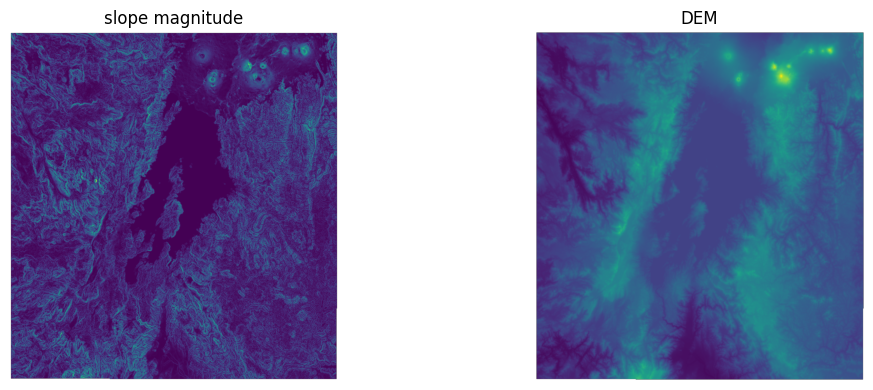

In [98]:
# === Timing (robust integer seconds) + wind + terrain gradients ===
import numpy as np
from scipy.special import erf as ERF

duration_s  = int(round(scenario_bp["duration_h"] * 3600))
dt          = float(scenario_bp["dt_internal_s"])

dt_report_s = int(scenario_bp["dt_report_min"] * 60)
save_img_s  = int(scenario_bp["save_images_every_min"] * 60)
sub_s       = int(scenario_bp["exposure_substep_min"] * 60)

# sanity: dt must divide report/sub/save intervals approximately
def assert_multiple(label, big, small):
    if abs((big / small) - round(big / small)) > 1e-9:
        print(f"[WARN] {label}={big} not an integer multiple of dt={small}. Will use rounded cadence.")
    else:
        print(f"[OK] {label} multiple of dt.")

assert_multiple("dt_report_s", dt_report_s, dt)
assert_multiple("save_img_s",  save_img_s,  dt)
assert_multiple("sub_s",       sub_s,       dt)

n_steps = int(np.ceil(duration_s / dt))
report_every = max(1, int(round(dt_report_s / dt)))
save_every   = max(1, int(round(save_img_s  / dt)))
sub_every    = max(1, int(round(sub_s       / dt)))

print("[TIME] duration_s:", duration_s, "dt:", dt, "n_steps:", n_steps)
print("[TIME] report every:", report_every, "steps =>", report_every*dt/60, "min")
print("[TIME] save   every:", save_every,   "steps =>", save_every*dt/60, "min")
print("[TIME] sub    every:", sub_every,    "steps =>", sub_every*dt/60, "min")

# Wind conversion
def wind_to_uv(speed_mps, dir_from_deg):
    dir_to = (dir_from_deg + 180.0) % 360.0
    rad = np.deg2rad(dir_to)
    u = speed_mps * np.sin(rad)   # +x east
    v = speed_mps * np.cos(rad)   # +y north
    return float(u), float(v)

u_wind, v_wind = wind_to_uv(scenario_bp["wind_speed_mps"], scenario_bp["wind_dir_deg_from"])
wind_mag = float(np.hypot(u_wind, v_wind))
print("[WIND] u,v:", u_wind, v_wind, "| |wind|:", wind_mag)

# Precompute terrain slopes (e = DEM)
# NOTE: dem is float32, dx/dy in meters already in your notebook state
dz_dy, dz_dx = np.gradient(dem.astype("float32"), dy, dx)  # d/drow, d/dcol -> dy, dx
print("[TERRAIN] dz_dx/dz_dy stats:")
print("  dz_dx pctl:", np.percentile(dz_dx[np.isfinite(dz_dx)], [1,5,50,95,99]))
print("  dz_dy pctl:", np.percentile(dz_dy[np.isfinite(dz_dy)], [1,5,50,95,99]))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(np.hypot(dz_dx, dz_dy)); plt.title("slope magnitude"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(dem); plt.title("DEM"); plt.axis("off")
plt.tight_layout(); plt.show()

[ERUPTION] disk_px: 256 disk_area_km2: 16.0


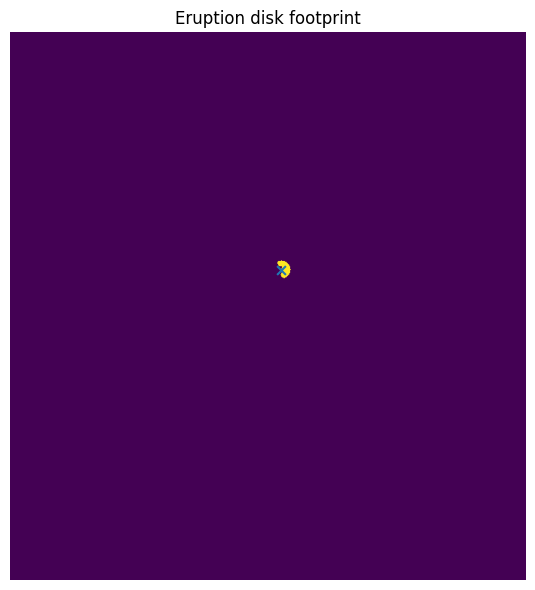

[ERUPTION] released_V: 3.000e+11 m3 STP | M_total: 5.520e+11 kg | m_area: 3.450e+04 kg/m2
[ERUPTION] initial h0 (m) inside disk: 1.87e+04
[PRECHECK] h nonzero cells: 256 h max: 18750.0
[PRECHECK] M_base sum kg: 552000028672.0 target kg: 552000000000.0


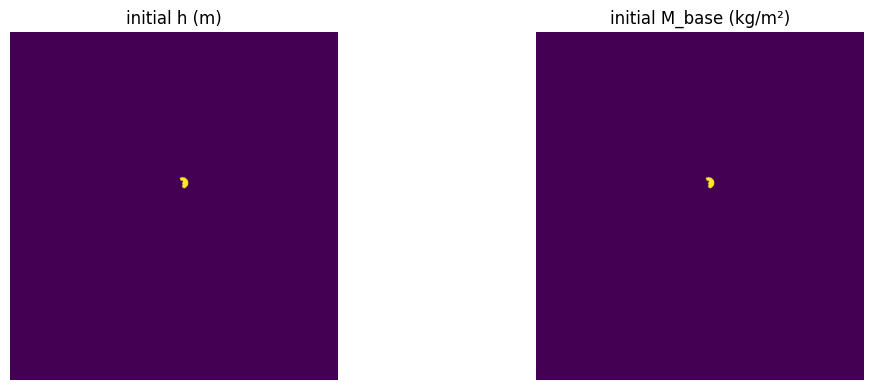

In [99]:
# === Initialize TWODEE-like base state (h,mx,my,M_base) and top mass M_top ===

def disk_mask(H, W, center_r, center_c, radius_m, dx, dy, mask_limit=None):
    rr = np.arange(H)[:, None]
    cc = np.arange(W)[None, :]
    dr_m = (rr - center_r) * dy
    dc_m = (cc - center_c) * dx
    disk = ((dr_m**2 + dc_m**2) <= radius_m**2).astype(np.uint8)
    if mask_limit is not None:
        disk = (disk & mask_limit.astype(np.uint8)).astype(np.uint8)
    return disk

limit_mask = mask_lake if scenario_bp["constrain_disk_to_lake"] else None
disk = disk_mask(H, W, src_r, src_c, scenario_bp["eruption_radius_m"], dx, dy, mask_limit=limit_mask)

disk_px = int(disk.sum())
disk_area_m2 = float(disk_px * cell_area)
print("[ERUPTION] disk_px:", disk_px, "disk_area_km2:", disk_area_m2/1e6)
assert disk_px > 0, "Disk empty. Increase radius or disable constrain_disk_to_lake."

plt.figure(figsize=(7,6))
plt.imshow(disk); plt.scatter([src_c],[src_r], s=40, marker="x")
plt.title("Eruption disk footprint"); plt.axis("off")
plt.tight_layout(); plt.show()

# Convert released volume (STP) -> mass using rho_co2_ref (scenario-level approximation)
released_V = float(scenario_bp["released_volume_STP_m3"])
rho_co2 = float(scenario_bp["rho_co2_ref"])
M_total_kg = released_V * rho_co2

# Uniform CO2 mass per area on disk (kg/m^2)
m_area = M_total_kg / (disk_area_m2 + 1e-12)
print("[ERUPTION] released_V:", f"{released_V:.3e} m3 STP",
      "| M_total:", f"{M_total_kg:.3e} kg",
      "| m_area:", f"{m_area:.3e} kg/m2")

# Initialize base layer depth assuming initially nearly pure CO2 layer:
# M_area = rho_co2 * h  ->  h0 = M_area / rho_co2 = released_V / area
h0 = m_area / (rho_co2 + 1e-12)  # meters
print("[ERUPTION] initial h0 (m) inside disk:", f"{h0:.3g}")

# State arrays
h = np.zeros((H, W), dtype="float32")
mx = np.zeros((H, W), dtype="float32")
my = np.zeros((H, W), dtype="float32")
M_base = np.zeros((H, W), dtype="float32")  # kg/m^2
M_top  = np.zeros((H, W), dtype="float32")  # kg/m^2

h[disk == 1] = h0
M_base[disk == 1] = m_area

print("[PRECHECK] h nonzero cells:", int(np.sum(h > 0)), "h max:", float(np.max(h)))
print("[PRECHECK] M_base sum kg:", float(np.sum(M_base) * cell_area), "target kg:", M_total_kg)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(h); plt.title("initial h (m)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(M_base); plt.title("initial M_base (kg/m²)"); plt.axis("off")
plt.tight_layout(); plt.show()

In [100]:
# === TWODEE-like shallow-layer update helpers (Rusanov + topo forcing) ===

g = float(scenario_bp["g"])
rho_air = float(scenario_bp["rho_air_ref"])
rho_co2 = float(scenario_bp["rho_co2_ref"])

def clip_nonneg(x): 
    return np.maximum(x, 0.0).astype("float32")

def co2_massfrac(M_base, h):
    # Approx CO2 volume/mass fraction proxy in the dense layer:
    # If layer is pure CO2: M = rho_co2*h => frac=1. Otherwise scales down.
    denom = (rho_co2 * h + 1e-12)
    f = np.clip(M_base / denom, 0.0, 1.0).astype("float32")
    return f

def rho_bar_from_frac(f):
    return (rho_air + f*(rho_co2 - rho_air)).astype("float32")

def reduced_gravity(rho_bar):
    # g' = g * (rho_bar - rho_air)/rho_air
    return (g * (rho_bar - rho_air) / (rho_air + 1e-12)).astype("float32")

def flux_x(h, mx, my, M_base, gp):
    u, v = primitives(h, mx, my)
    p = 0.5 * gp * h * h
    Fh  = mx
    Fmx = mx*u + p
    Fmy = my*u
    FM  = M_base*u
    return Fh, Fmx, Fmy, FM

def flux_y(h, mx, my, M_base, gp):
    u, v = primitives(h, mx, my)
    p = 0.5 * gp * h * h
    Gh  = my
    Gmx = mx*v
    Gmy = my*v + p
    GM  = M_base*v
    return Gh, Gmx, Gmy, GM

def rusanov_flux(F_L, F_R, Q_L, Q_R, amax):
    # Numerical flux = 0.5(F_L+F_R) - 0.5*amax*(Q_R-Q_L)
    return 0.5*(F_L + F_R) - 0.5*amax*(Q_R - Q_L)

def diffuse(F, K, dt, dx, dy):
    if K <= 0:
        return F
    F = F.astype("float32")
    L = np.pad(F, ((0,0),(1,0)), mode="edge")[:, :-1]
    R = np.pad(F, ((0,0),(0,1)), mode="edge")[:, 1:]
    U = np.pad(F, ((1,0),(0,0)), mode="edge")[:-1, :]
    D = np.pad(F, ((0,1),(0,0)), mode="edge")[1:, :]
    lap = (L - 2*F + R)/(dx*dx) + (U - 2*F + D)/(dy*dy)
    return (F + (K*dt)*lap).astype("float32")

def apply_friction(mx, my, h, Cf, dt):
    # quadratic friction: m <- m - Cf * u|u| * h * dt  (proxy)
    u, v = primitives(h, mx, my)
    speed = np.sqrt(u*u + v*v).astype("float32")
    mx2 = mx - (Cf * u * speed * h * dt).astype("float32")
    my2 = my - (Cf * v * speed * h * dt).astype("float32")
    return mx2.astype("float32"), my2.astype("float32")

def topo_forcing(mx, my, gp, h, dz_dx, dz_dy, dt):
    # shallow-water style source: -g' * h * grad(e)
    mx2 = mx - (gp * h * dz_dx * dt).astype("float32")
    my2 = my - (gp * h * dz_dy * dt).astype("float32")
    return mx2.astype("float32"), my2.astype("float32")

# === Robust dry-cell primitives (prevents divide-by-zero and blowups) ===
H_FLOOR = 1e-4  # meters; below this we treat as dry

def primitives(h, mx, my):
    """
    Dry-cell safe velocity reconstruction.
    u=v=0 where h is tiny.
    """
    h = h.astype("float32")
    mx = mx.astype("float32")
    my = my.astype("float32")

    u = np.zeros_like(h, dtype="float32")
    v = np.zeros_like(h, dtype="float32")

    wet = h > H_FLOOR
    u[wet] = mx[wet] / h[wet]
    v[wet] = my[wet] / h[wet]
    return u, v

def enforce_positivity_and_consistency(h, mx, my, M_base, rho_co2):
    """
    Enforce:
    - h >= 0
    - M_base >= 0
    - M_base <= rho_co2 * h  (cannot exceed pure CO2 in that layer)
    - dry cells have mx=my=0
    """
    h = np.maximum(h, 0.0).astype("float32")
    M_base = np.maximum(M_base, 0.0).astype("float32")

    # cap mass to physically possible given depth
    cap = (rho_co2 * h).astype("float32")
    M_base = np.minimum(M_base, cap).astype("float32")

    dry = h <= H_FLOOR
    mx = mx.astype("float32")
    my = my.astype("float32")
    mx[dry] = 0.0
    my[dry] = 0.0
    return h, mx, my, M_base

In [101]:
# === Paper-grounded concentration at z + lethality ===

def rho_at_height_z(h_eff, rho_bar, rho_air, S1, z):
    h = np.maximum(h_eff, 1e-6).astype("float32")
    term = (2.0 / (S1 + 1e-12)) * (rho_bar - rho_air)
    expo = np.exp(-(2.0 / (S1 + 1e-12)) * (z / h)).astype("float32")
    rho_z = (rho_air + term * expo).astype("float32")
    rho_z = np.where(h_eff <= 0, rho_air, rho_z).astype("float32")
    return rho_z

def ppm_from_rho(rho_z, rho_air, rho_co2, c_background_ppm):
    frac = (rho_z - rho_air) / ((rho_co2 - rho_air) + 1e-12)
    frac = np.clip(frac, 0.0, 1.0).astype("float32")
    ppm = (c_background_ppm + (1e6 - c_background_ppm) * frac).astype("float32")
    return ppm

def prob_death_from_ppm(ppm, exposure_min, pars):
    # vectorized Eq 7–9
    c_percent = (ppm / 1e4).astype("float32")  # ppm -> %
    d_min = exposure_min.astype("float32")

    mu = pars["fatal_a0"] + pars["fatal_b0"] / (1.0 + np.power(d_min, pars["fatal_c0"]))
    sig = pars["fatal_a1"] + pars["fatal_b1"] / (1.0 + np.power(d_min, pars["fatal_c1"]))
    z = (c_percent - mu) / (np.sqrt(2.0) * (sig + 1e-12))
    P = (0.5 * (1.0 + ERF(z))).astype("float32")
    return np.clip(P, 0.0, 1.0).astype("float32")

In [102]:
# === Correct Rusanov finite-volume update for TWODEE-like shallow-layer ===
def shiftR(A): return np.pad(A, ((0,0),(0,1)), mode="edge")[:, 1:]
def shiftL(A): return np.pad(A, ((0,0),(1,0)), mode="edge")[:, :-1]
def shiftD(A): return np.pad(A, ((0,1),(0,0)), mode="edge")[1:, :]
def shiftU(A): return np.pad(A, ((1,0),(0,0)), mode="edge")[:-1, :]

def compute_gp(M_base, h, rho_air, rho_co2, g):
    """
    Compute reduced gravity g' = g*(rho_bar - rho_air)/rho_air
    where rho_bar = rho_air + f*(rho_co2-rho_air), f = M/(rho_co2*h).
    Ensures non-negative g'.
    """
    f = np.zeros_like(h, dtype="float32")
    wet = h > H_FLOOR
    f[wet] = np.clip(M_base[wet] / (rho_co2*h[wet] + 1e-12), 0.0, 1.0)
    rho_bar = (rho_air + f*(rho_co2 - rho_air)).astype("float32")
    gp = (g * (rho_bar - rho_air) / (rho_air + 1e-12)).astype("float32")
    gp = np.maximum(gp, 0.0).astype("float32")
    return gp, rho_bar, f

def flux_x_state(h, mx, my, M, gp):
    u, v = primitives(h, mx, my)
    p = 0.5 * gp * h * h
    Fh  = mx
    Fmx = mx*u + p
    Fmy = my*u
    FM  = M*u
    return Fh, Fmx, Fmy, FM, u

def flux_y_state(h, mx, my, M, gp):
    u, v = primitives(h, mx, my)
    p = 0.5 * gp * h * h
    Gh  = my
    Gmx = mx*v
    Gmy = my*v + p
    GM  = M*v
    return Gh, Gmx, Gmy, GM, v

def rusanov_interface(F_L, F_R, Q_L, Q_R, amax):
    return 0.5*(F_L + F_R) - 0.5*amax*(Q_R - Q_L)

def twodee_step(h, mx, my, M_base, dt, dx, dy, rho_air, rho_co2, g,
                dz_dx, dz_dy, Cf, K_h, K_m, K_M):
    """
    One explicit time step with:
    - finite-volume Rusanov fluxes
    - topo source: -g' h grad(e)
    - quadratic friction on momentum
    - small Laplacian diffusion (stabilization)
    """
    # enforce state sanity before fluxes
    h, mx, my, M_base = enforce_positivity_and_consistency(h, mx, my, M_base, rho_co2)

    gp, rho_bar, f = compute_gp(M_base, h, rho_air, rho_co2, g)

    # ---------- X direction interfaces ----------
    hR, mxR, myR, MR, gpR = shiftR(h), shiftR(mx), shiftR(my), shiftR(M_base), shiftR(gp)

    FhL, FmxL, FmyL, FML, uL = flux_x_state(h,  mx,  my,  M_base, gp)
    FhR, FmxR, FmyR, FMR, uR = flux_x_state(hR, mxR, myR, MR,     gpR)

    cL = np.sqrt(np.maximum(gp*h,   0.0)).astype("float32")
    cR = np.sqrt(np.maximum(gpR*hR, 0.0)).astype("float32")
    amax_x = np.maximum(np.abs(uL)+cL, np.abs(uR)+cR).astype("float32")
    amax_x = np.maximum(amax_x, 1e-6)

    Fx_h  = rusanov_interface(FhL,  FhR,  h,  hR,  amax_x)
    Fx_mx = rusanov_interface(FmxL, FmxR, mx, mxR, amax_x)
    Fx_my = rusanov_interface(FmyL, FmyR, my, myR, amax_x)
    Fx_M  = rusanov_interface(FML,  FMR,  M_base, MR, amax_x)

    # divergence (Fx(i+1/2) - Fx(i-1/2)) / dx
    h  = h  - (dt/dx) * (Fx_h  - shiftL(Fx_h))
    mx = mx - (dt/dx) * (Fx_mx - shiftL(Fx_mx))
    my = my - (dt/dx) * (Fx_my - shiftL(Fx_my))
    M_base = M_base - (dt/dx) * (Fx_M - shiftL(Fx_M))

    # ---------- Y direction interfaces ----------
    hD, mxD, myD, MD, gpD = shiftD(h), shiftD(mx), shiftD(my), shiftD(M_base), shiftD(gp)

    GhL, GmxL, GmyL, GML, vL = flux_y_state(h,  mx,  my,  M_base, gp)
    GhD, GmxD, GmyD, GMD, vD = flux_y_state(hD, mxD, myD, MD,     gpD)

    cL = np.sqrt(np.maximum(gp*h,   0.0)).astype("float32")
    cD = np.sqrt(np.maximum(gpD*hD, 0.0)).astype("float32")
    amax_y = np.maximum(np.abs(vL)+cL, np.abs(vD)+cD).astype("float32")
    amax_y = np.maximum(amax_y, 1e-6)

    Gy_h  = rusanov_interface(GhL,  GhD,  h,  hD,  amax_y)
    Gy_mx = rusanov_interface(GmxL, GmxD, mx, mxD, amax_y)
    Gy_my = rusanov_interface(GmyL, GmyD, my, myD, amax_y)
    Gy_M  = rusanov_interface(GML,  GMD,  M_base, MD, amax_y)

    h  = h  - (dt/dy) * (Gy_h  - shiftU(Gy_h))
    mx = mx - (dt/dy) * (Gy_mx - shiftU(Gy_mx))
    my = my - (dt/dy) * (Gy_my - shiftU(Gy_my))
    M_base = M_base - (dt/dy) * (Gy_M - shiftU(Gy_M))

    # ---------- Topography forcing (source term) ----------
    # mx,my <- mx - g' h dz/dx dt ; my <- my - g' h dz/dy dt
    gp_now, _, _ = compute_gp(M_base, h, rho_air, rho_co2, g)
    mx = mx - (gp_now * h * dz_dx * dt).astype("float32")
    my = my - (gp_now * h * dz_dy * dt).astype("float32")

    # ---------- Friction ----------
    mx, my = apply_friction(mx, my, h, Cf, dt)

    # ---------- Numerical diffusion (stabilization) ----------
    h      = diffuse(h,      K_h, dt, dx, dy)
    mx     = diffuse(mx,     K_m, dt, dx, dy)
    my     = diffuse(my,     K_m, dt, dx, dy)
    M_base = diffuse(M_base, K_M, dt, dx, dy)

    # final clamp
    h, mx, my, M_base = enforce_positivity_and_consistency(h, mx, my, M_base, rho_co2)
    return h, mx, my, M_base

In [103]:
# === Health checks: CFL + NaN trap ===
def check_health(step, t_min, h, mx, my, M_base, rho_air, rho_co2, g):
    gp, _, _ = compute_gp(M_base, h, rho_air, rho_co2, g)
    u, v = primitives(h, mx, my)
    c = np.sqrt(np.maximum(gp*h, 0.0))
    umax = float(np.nanmax(np.abs(u) + c))
    vmax = float(np.nanmax(np.abs(v) + c))
    dt_cfl = min(dx/(umax+1e-12), dy/(vmax+1e-12)) * 0.4  # 0.4 safety

    # NaN/Inf checks
    bad = (
        np.isnan(h).any() or np.isnan(mx).any() or np.isnan(my).any() or np.isnan(M_base).any() or
        np.isinf(h).any() or np.isinf(mx).any() or np.isinf(my).any() or np.isinf(M_base).any()
    )
    if bad:
        print(f"[FATAL] NaN/Inf detected at t={t_min:.1f} min step={step}")
        print("  h nan:", int(np.isnan(h).sum()), " mx nan:", int(np.isnan(mx).sum()),
              " my nan:", int(np.isnan(my).sum()), " M nan:", int(np.isnan(M_base).sum()))
        raise FloatingPointError("NaN/Inf detected. Reduce dt or adjust parameters.")

    # Print occasionally
    if step % max(1, int(round(60/dt))) == 0:  # about every minute of sim time
        print(f"[HEALTH] t={t_min:7.1f} min | h_max={float(np.max(h)):.3g} | "
              f"M_sum={float(np.sum(M_base)*cell_area):.3e} kg | "
              f"umax≈{umax:.3g} m/s | CFL_dt≈{dt_cfl:.2f} s")
        if dt > dt_cfl:
            print(f"[WARN] dt={dt} exceeds CFL_dt≈{dt_cfl:.2f}. Lower dt_internal_s.")

In [104]:
# === PRE-RUN CADENCE ASSERTS (prevents empty metrics after long runs) ===
print("\n[CADENCE]")
print("  dt (s):", dt)
print("  n_steps:", n_steps)
print("  report_every (steps):", report_every, "=>", report_every * dt, "seconds")
print("  sub_every (steps):", sub_every, "=>", sub_every * dt, "seconds")
print("  save_every (steps):", save_every, "=>", save_every * dt, "seconds")

assert report_every >= 1, "report_every must be >= 1"
assert report_every <= n_steps, f"report_every={report_every} is > n_steps={n_steps} (would yield no reports)"
assert int(0 % report_every) == 0, "sanity"
print("[CADENCE] OK — reporting should occur during run.")


[CADENCE]
  dt (s): 0.3
  n_steps: 84000
  report_every (steps): 200 => 60.0 seconds
  sub_every (steps): 600 => 180.0 seconds
  save_every (steps): 2000 => 600.0 seconds
[CADENCE] OK — reporting should occur during run.


In [105]:
# === RUN (Better Physics) — TWODEE-like base + wind top ===

THRESH_DANGER = 50_000.0
THRESH_LETHAL = 100_000.0

RUN_DIR_BP = RUNS_DIR / f"single_run_better_physics"
RUN_DIR_BP.mkdir(parents=True, exist_ok=True)
print("[RUN_BP] Output dir:", RUN_DIR_BP)

(Path(RUN_DIR_BP) / "scenario_bp.json").write_text(json.dumps(scenario_bp, indent=2))

# --- Safety defaults to prevent KeyErrors ---
scenario_bp.setdefault("base_background_loss_1ps", 2.0e-6)
scenario_bp.setdefault("top_background_loss_1ps", 0.0)
scenario_bp.setdefault("strip_coeff_1ps_per_mps", 2.0e-4)
scenario_bp.setdefault("entrain_rate_1ps", 2.0e-5)
scenario_bp.setdefault("entrain_wind_gain", 1.0)
scenario_bp.setdefault("K_top_m2ps", 20.0)
scenario_bp.setdefault("K_h_m2ps", 0.5)
scenario_bp.setdefault("K_M_m2ps", 0.5)
scenario_bp.setdefault("K_m_m2ps", 0.2)

#Experimental Run
scenario_bp["duration_h"] = 0.0833333  # 5 minutes

print("[SCENARIO_BP] key params:",
      "dt=", dt,
      "Cf=", scenario_bp.get("Cf_friction", None),
      "K_h=", scenario_bp["K_h_m2ps"],
      "K_M=", scenario_bp["K_M_m2ps"],
      "K_m=", scenario_bp["K_m_m2ps"],
      "K_top=", scenario_bp["K_top_m2ps"],
      "entrain=", scenario_bp["entrain_rate_1ps"],
      "strip_coeff=", scenario_bp["strip_coeff_1ps_per_mps"],
      "base_loss=", scenario_bp["base_background_loss_1ps"])

# Exposure tracking
exposure_min = np.zeros((H, W), dtype="float32")

# Cumulative coupling/loss accounting
cum_entr_kg = 0.0
cum_strip_kg = 0.0
cum_base_loss_kg = 0.0

metrics_rows = []

# =========================
# Helpers (keep as you had)
# =========================
def snapshot(t_min, h, M_base, M_top, ppm, Pdeath):
    fig, ax = plt.subplots(2, 3, figsize=(16, 10))
    ax[0,0].imshow(h);      ax[0,0].set_title(f"h (m) t={t_min:.0f}min"); ax[0,0].axis("off")
    ax[0,1].imshow(M_base); ax[0,1].set_title("M_base (kg/m²)");          ax[0,1].axis("off")
    ax[0,2].imshow(M_top);  ax[0,2].set_title("M_top (kg/m²)");           ax[0,2].axis("off")

    im = ax[1,0].imshow(ppm); ax[1,0].set_title(f"ppm(z={scenario_bp['z_human_m']}m)"); ax[1,0].axis("off")
    ax[1,1].imshow((ppm>=THRESH_LETHAL).astype(np.uint8)); ax[1,1].set_title("lethal mask"); ax[1,1].axis("off")
    ax[1,2].imshow(Pdeath); ax[1,2].set_title("P(death)"); ax[1,2].axis("off")

    for a in ax.ravel():
        a.scatter([src_c],[src_r], s=25, marker="x")

    plt.colorbar(im, ax=ax[1,0], fraction=0.046, pad=0.04)
    plt.tight_layout()
    out = RUN_DIR_BP / f"snapshot_t{int(t_min):04d}m.png"
    fig.savefig(out, dpi=140)
    plt.close(fig)
    print("[PLOT_BP] saved", out.name)

def compute_metrics_row(t_min, h, mx, my, M_base, M_top, ppm, Pdeath, exposure_min):
    pop_safe = np.where(np.isfinite(pop), pop, 0.0)

    danger = (ppm >= THRESH_DANGER)
    lethal = (ppm >= THRESH_LETHAL)

    area_danger_km2 = float(danger.sum() * cell_area / 1e6)
    area_lethal_km2 = float(lethal.sum() * cell_area / 1e6)
    pop_danger = float(np.sum(pop_safe[danger]))
    pop_lethal = float(np.sum(pop_safe[lethal]))
    expected_fatalities = float(np.sum(pop_safe * Pdeath))

    vol_base_m3 = float(np.sum(h) * cell_area)                 # geometric volume of base layer (m³)
    mass_base_kg = float(np.sum(M_base) * cell_area)
    mass_top_kg  = float(np.sum(M_top) * cell_area)

    max_ppm = float(np.nanmax(ppm))
    p95_ppm = float(np.nanpercentile(ppm[np.isfinite(ppm)], 95)) if np.isfinite(ppm).any() else np.nan

    u, v = primitives(h, mx, my)
    speed = np.sqrt(u*u + v*v)
    vmax_flow = float(np.nanmax(speed))

    return {
        "time_min": float(t_min),
        "time_hr": float(t_min/60.0),

        "vol_base_geom_m3": vol_base_m3,
        "mass_base_kg": mass_base_kg,
        "mass_top_kg": mass_top_kg,

        "cum_entrained_kg": float(cum_entr_kg),
        "cum_stripped_kg": float(cum_strip_kg),
        "cum_base_loss_kg": float(cum_base_loss_kg),

        "max_ppm_z": max_ppm,
        "p95_ppm_z": p95_ppm,

        "area_danger_km2": area_danger_km2,
        "area_lethal_km2": area_lethal_km2,
        "pop_danger": pop_danger,
        "pop_lethal": pop_lethal,
        "expected_fatalities": expected_fatalities,

        "max_flow_speed_mps": vmax_flow,
        "mean_exposure_min": float(np.mean(exposure_min)),
        "max_exposure_min": float(np.max(exposure_min)),
        "max_Pdeath": float(np.max(Pdeath)),
    }

# =========================
# Run loop (uses twodee_step)
# =========================
print("\n[SIM_BP] starting loop...")

# Ensure ppm/Pdeath not stale across reruns
ppm = None
Pdeath = np.zeros((H, W), dtype="float32")
from tqdm import tqdm

for step in tqdm(range(n_steps + 1)):
    t_s = step * dt
    t_min = t_s / 60.0

    # --- Base layer update (TWODEE-like, stable wiring) ---
    h, mx, my, M_base = twodee_step(
        h, mx, my, M_base,
        dt=dt, dx=dx, dy=dy,
        rho_air=rho_air, rho_co2=rho_co2, g=g,
        dz_dx=dz_dx.astype("float32"), dz_dy=dz_dy.astype("float32"),
        Cf=float(scenario_bp.get("Cf_friction", 0.002)),
        K_h=float(scenario_bp["K_h_m2ps"]),
        K_m=float(scenario_bp["K_m_m2ps"]),
        K_M=float(scenario_bp["K_M_m2ps"]),
    )

    # --- Health check (CFL + NaN trap) ---
    check_health(step, t_min, h, mx, my, M_base, rho_air, rho_co2, g)

    # --- Coupling: entrain base -> top (CO2 mass only) ---
    entrain_eff = scenario_bp["entrain_rate_1ps"] * (1.0 + scenario_bp["entrain_wind_gain"] * wind_mag)
    dM = (entrain_eff * dt) * M_base
    dM = np.minimum(dM, M_base)
    M_base -= dM
    M_top  += dM
    cum_entr_kg += float(np.sum(dM) * cell_area)

    # Re-enforce consistency after entrainment
    h, mx, my, M_base = enforce_positivity_and_consistency(h, mx, my, M_base, rho_co2)

    # --- Base background loss (mass + implied depth reduction) ---
    base_loss = float(scenario_bp["base_background_loss_1ps"])
    if base_loss > 0:
        dM_loss = (1.0 - np.exp(-base_loss * dt)) * M_base
        M_base -= dM_loss
        cum_base_loss_kg += float(np.sum(dM_loss) * cell_area)
        # keep h consistent with new mass (cap already enforced)
        h, mx, my, M_base = enforce_positivity_and_consistency(h, mx, my, M_base, rho_co2)

    # --- Top layer wind advection + diffusion + stripping (DISGAS-like) ---
    def advect_upwind_scalar(F, u, v, dt, dx, dy):
        L = np.pad(F, ((0,0),(1,0)), mode="edge")[:, :-1]
        R = np.pad(F, ((0,0),(0,1)), mode="edge")[:, 1:]
        U = np.pad(F, ((1,0),(0,0)), mode="edge")[:-1, :]
        D = np.pad(F, ((0,1),(0,0)), mode="edge")[1:, :]
        dFdx = np.where(u >= 0, (F - L)/dx, (R - F)/dx)
        dFdy = np.where(v >= 0, (F - U)/dy, (D - F)/dy)
        return (F - dt*(u*dFdx + v*dFdy)).astype("float32")

    M_top = advect_upwind_scalar(M_top, u_wind, v_wind, dt, dx, dy)
    M_top = diffuse(M_top, float(scenario_bp["K_top_m2ps"]), dt, dx, dy)
    M_top = np.maximum(M_top, 0).astype("float32")

    strip_rate = float(scenario_bp["strip_coeff_1ps_per_mps"]) * wind_mag + float(scenario_bp["top_background_loss_1ps"])
    if strip_rate > 0:
        before = float(np.sum(M_top) * cell_area)
        M_top = (M_top * np.exp(-strip_rate * dt)).astype("float32")
        after  = float(np.sum(M_top) * cell_area)
        cum_strip_kg += max(0.0, before - after)

    # --- Exposure substep: compute ppm(z) and Pdeath ---
    if step % sub_every == 0:
        # Base: infer fraction and rho_bar
        f_base = co2_massfrac(M_base, h)
        rho_bar_base = rho_bar_from_frac(f_base)

        # Conservative near-ground inclusion of top: convert to equivalent depth and add for hazard only
        h_top_equiv = (M_top / (rho_co2 + 1e-12)).astype("float32")
        h_eff = (h + h_top_equiv).astype("float32")

        rho_z = rho_at_height_z(h_eff, rho_bar_base, rho_air, scenario_bp["S1"], scenario_bp["z_human_m"])
        ppm = ppm_from_rho(rho_z, rho_air, rho_co2, scenario_bp["c_background_ppm"])

        # exposure accumulation
        exposure_min += (ppm >= scenario_bp["exposure_threshold_ppm"]).astype("float32") * scenario_bp["exposure_substep_min"]

        # probability of death
        Pdeath = prob_death_from_ppm(ppm, exposure_min, scenario_bp)

        # Debug print every ~hour
        if step % max(1, int(round(3600/dt))) == 0:
            tqdm.write(f"[t={t_min:7.1f} min] ppm max={float(np.nanmax(ppm)):.3g} | "
                  f"h max={float(np.nanmax(h)):.3g} | M_base_sum={float(np.nansum(M_base)*cell_area):.3e} kg | "
                  f"M_top_sum={float(np.nansum(M_top)*cell_area):.3e} kg | Pmax={float(np.nanmax(Pdeath)):.3f}")

        # NaN guard
        if np.isnan(ppm).any() or np.isnan(Pdeath).any():
            tqdm.write("[FATAL] NaN in hazard outputs at t_min=", t_min)
            raise FloatingPointError("NaN in ppm/Pdeath. Check h_eff/rho computations.")
    
    # --- Exposure substep (keeps ppm & Pdeath fresh) ---
    if step % sub_every == 0:
        # (compute ppm, exposure_min, Pdeath here as you already do)
        # AFTER computing:
        if np.isnan(ppm).any() or np.isnan(Pdeath).any():
            print("[FATAL] NaN in ppm/Pdeath at step=", step, "t_min=", t_min)
            raise FloatingPointError("NaN in hazard outputs")
    
    # --- Reporting (every dt_report) ---
    if step % report_every == 0:
        # Ensure ppm/Pdeath exist even if sub_every > report_every
        if (ppm is None) or (not np.isfinite(ppm).all()):
            # recompute ppm & Pdeath quickly (same code you use in substep)
            f_base = co2_massfrac(M_base, h)
            rho_bar_base = rho_bar_from_frac(f_base)
            h_top_equiv = (M_top / (rho_co2 + 1e-12)).astype("float32")
            h_eff = (h + h_top_equiv).astype("float32")
            rho_z = rho_at_height_z(h_eff, rho_bar_base, rho_air, scenario_bp["S1"], scenario_bp["z_human_m"])
            ppm = ppm_from_rho(rho_z, rho_air, rho_co2, scenario_bp["c_background_ppm"])
            Pdeath = prob_death_from_ppm(ppm, exposure_min, scenario_bp)
    
        row = compute_metrics_row(t_min, h, mx, my, M_base, M_top, ppm, Pdeath, exposure_min)
        metrics_rows.append(row)
    
        if len(metrics_rows) <= 3:
            print(f"[REPORT] step={step} t_min={t_min:.2f} rows={len(metrics_rows)} max_ppm={row['max_ppm_z']:.3g}")
    
    # --- Snapshots (every hour) ---
    if step % save_every == 0:
        if ppm is not None:
            snapshot(t_min, h, M_base, M_top, ppm, Pdeath)
    
    # --- Checkpoint metrics every hour (prevents 19h wasted again) ---
    if step % save_every == 0 and len(metrics_rows) > 0:
        pd.DataFrame(metrics_rows).to_csv(RUN_DIR_BP / "metrics_10min_partial.csv", index=False)
        print("[CHECKPOINT] wrote metrics_10min_partial.csv rows=", len(metrics_rows))
# Save metrics
metrics_df_bp = pd.DataFrame(metrics_rows)
metrics_path = RUN_DIR_BP / "metrics_10min.csv"
metrics_df_bp.to_csv(metrics_path, index=False)
print("\n[WRITE_BP] metrics:", metrics_path, "| rows:", len(metrics_df_bp), "| cols:", metrics_df_bp.shape[1])

print("\n[SUMMARY_BP]")
print("  max expected_fatalities:", float(metrics_df_bp["expected_fatalities"].max()))
print("  max pop_lethal:", float(metrics_df_bp["pop_lethal"].max()))
print("  max area_lethal_km2:", float(metrics_df_bp["area_lethal_km2"].max()))

[RUN_BP] Output dir: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\runs\single_run_better_physics
[SCENARIO_BP] key params: dt= 0.3 Cf= 0.002 K_h= 0.5 K_M= 0.5 K_m= 0.2 K_top= 20.0 entrain= 2e-05 strip_coeff= 0.0002 base_loss= 2e-06

[SIM_BP] starting loop...


  0%|                                                                                        | 0/84001 [00:00<?, ?it/s]

[HEALTH] t=    0.0 min | h_max=1.88e+04 | M_sum=5.520e+11 kg | umax≈318 m/s | CFL_dt≈0.31 s


  0%|                                                                                        | 0/84001 [00:00<?, ?it/s]

[t=    0.0 min] ppm max=1e+06 | h max=1.88e+04 | M_base_sum=5.520e+11 kg | M_top_sum=9.935e+06 kg | Pmax=1.000
[REPORT] step=0 t_min=0.00 rows=1 max_ppm=1e+06


...

[HEALTH] t=  420.0 min | h_max=112 | M_sum=1.158e+11 kg | umax≈15 m/s | CFL_dt≈6.45 s


100%|████████████████████████████████████████████████████████████████████████▉| 84000/84001 [13:39:48<00:00,  2.18it/s]

[t=  420.0 min] ppm max=7.96e+05 | h max=112 | M_base_sum=1.158e+11 kg | M_top_sum=2.054e+10 kg | Pmax=1.000


100%|█████████████████████████████████████████████████████████████████████████| 84001/84001 [13:39:50<00:00,  1.71it/s]

[PLOT_BP] saved snapshot_t0420m.png
[CHECKPOINT] wrote metrics_10min_partial.csv rows= 421

[WRITE_BP] metrics: C:\Users\nachi\Data\GitHubProjects\Lake Kivu\kivu_limnic_scenarios\notebooks\runs\single_run_better_physics\metrics_10min.csv | rows: 421 | cols: 19

[SUMMARY_BP]
  max expected_fatalities: 2672342.0
  max pop_lethal: 2618301.75
  max area_lethal_km2: 3828.25


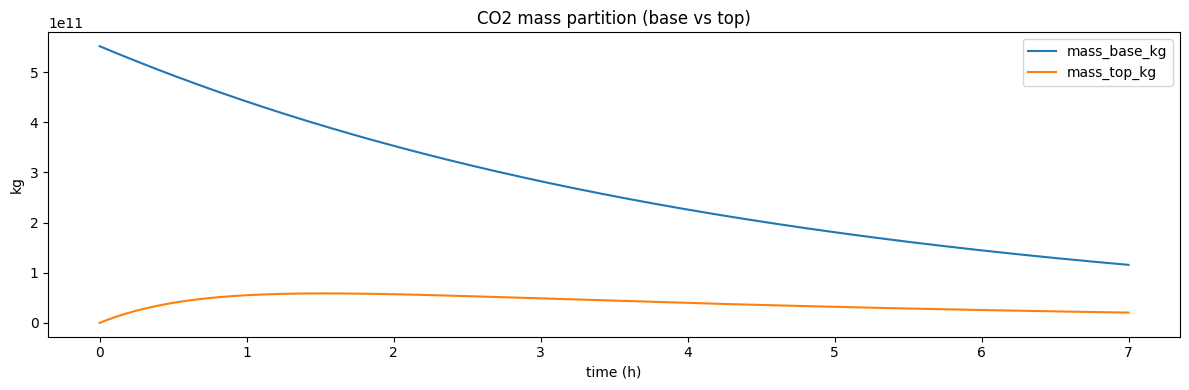

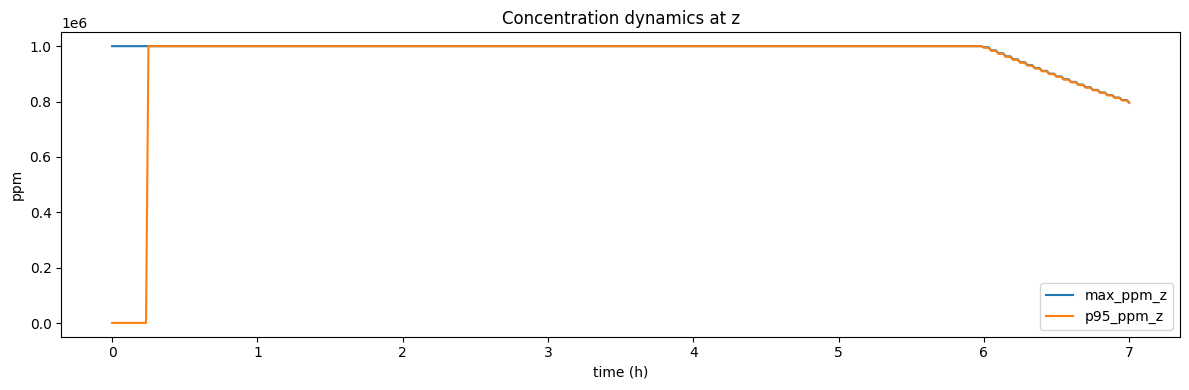

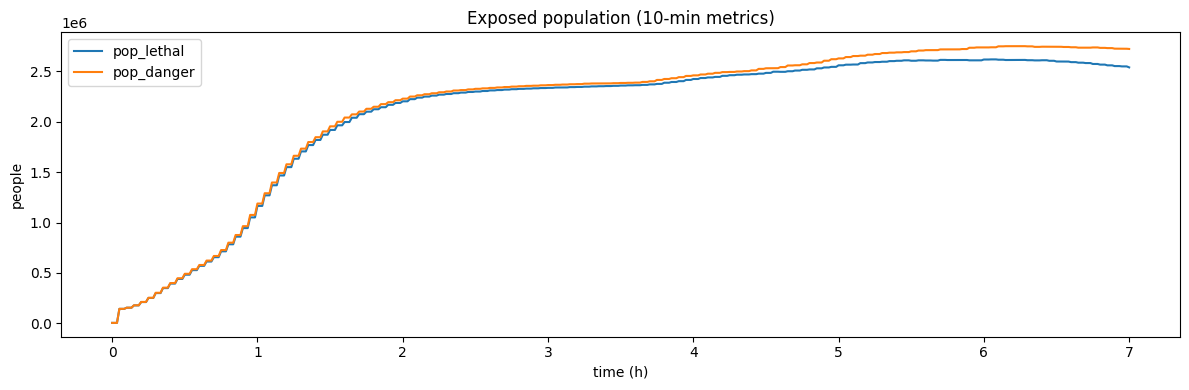

NameError: name 'plttight_layout' is not defined

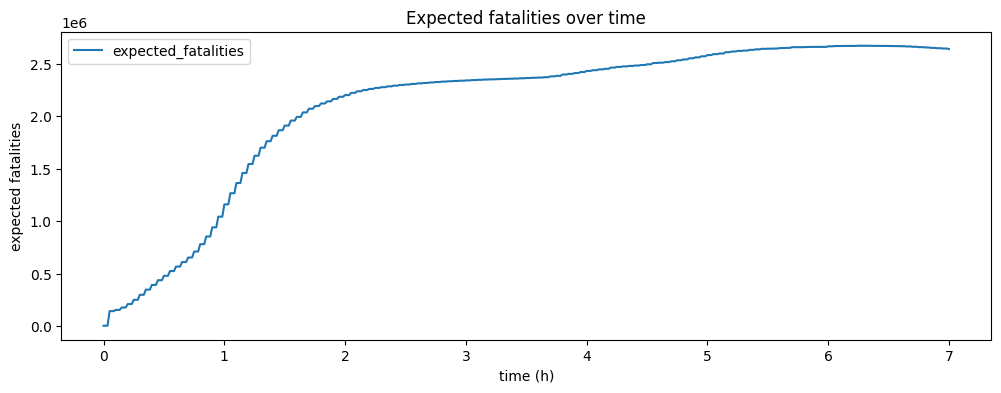

In [106]:
# === Better-Physics graphs (dynamics) ===
df = metrics_df_bp.copy()

plt.figure(figsize=(12,4))
plt.plot(df["time_hr"], df["mass_base_kg"], label="mass_base_kg")
plt.plot(df["time_hr"], df["mass_top_kg"], label="mass_top_kg")
plt.xlabel("time (h)"); plt.ylabel("kg"); plt.title("CO2 mass partition (base vs top)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["time_hr"], df["max_ppm_z"], label="max_ppm_z")
plt.plot(df["time_hr"], df["p95_ppm_z"], label="p95_ppm_z")
plt.xlabel("time (h)"); plt.ylabel("ppm"); plt.title("Concentration dynamics at z")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["time_hr"], df["pop_lethal"], label="pop_lethal")
plt.plot(df["time_hr"], df["pop_danger"], label="pop_danger")
plt.xlabel("time (h)"); plt.ylabel("people"); plt.title("Exposed population (10-min metrics)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["time_hr"], df["expected_fatalities"], label="expected_fatalities")
plt.xlabel("time (h)"); plt.ylabel("expected fatalities"); plt.title("Expected fatalities over time")
plt.legend(); plttight_layout(); plt.show()

# Lake Kivu Scenario Player — Web Viewer Plan (Staged)

This plan turns the current offline simulation into a browser-based scenario “video player” with MapLibre, precomputed scenario bundles, PNG overlays per timestep, and OSM-derived vector tiles generated from OSMnx features.  
Primary goals:
- **No physics in the browser** (fast playback).
- **Scenario selection via dropdown** (limited runs initially).
- **AOI-bounded view** (no wasted rendering).
- Save **GeoTIFFs for raw fields** (for analysis/3D later), but use **PNG overlays** for UI playback.
- Use **FastAPI** for local/dev first (debug-friendly), then **GitHub Pages** for static hosting.

---

## Stage 0 — Freeze the POC contract

**Decisions (POC):**
- Reporting timestep: **10 minutes** (fixed, not user-configurable).
- Scenario selection: **dropdown** (precomputed runs only).
- Viewer renders: **MapLibre** basemap (custom OSM vector tiles) + **PNG overlays** per timestep.
- Output storage: keep both:
  - **metrics CSV** (time series)
  - **manifest JSON** (scenario metadata)
  - **PNG frames** (one per timestep per layer)
  - optional **GeoTIFFs / Zarr** for raw arrays (for 3D and analysis)

**Deliverable:** A documented “scenario bundle” spec (see Stage 1).

---

## Stage 1 — Define a scenario bundle spec (files + metadata)

Create one folder per scenario:

```
scenarios/
  scenario_<id>/
    manifest.json
    metrics_10min.csv
    frames/
      ppm_z/
        t0000.png
        t0001.png
        ...
      lethal_mask/
        t0000.png
        ...
      pdeath/
        t0000.png
        ...
      base_h/            # optional (visual thickness)
        t0000.png
    raw/
      h_base.tif         # optional
      M_base.tif         # optional
      M_top.tif          # optional
      ppm_z.tif          # optional (or one GeoTIFF per timestep if needed)
      pdeath.tif         # optional
    geo/
      aoi.geojson
      lake_outline.geojson
      waterbodies.geojson
      osmnx.pmtiles      # vector tiles packaged as PMTiles
```

### `manifest.json` (minimum fields)
- `scenario_id`
- `created_utc`
- `aoi`: bbox in WGS84 + `maxBounds` for MapLibre
- `crs`: e.g., EPSG:32735
- `grid`:
  - `width`, `height`
  - `dx_m`, `dy_m`
  - affine transform coefficients OR bbox + resolution
- `time`:
  - `dt_report_min` (10)
  - `n_frames`
  - `timestamps_min` (array or computed)
- `parameters` (scenario knobs):
  - `release_fraction`, `released_volume_m3_stp`
  - `eruption_radius_m`
  - `wind_speed_mps`, `wind_dir_from_deg`
  - other key parameters you want surfaced
- `layers` (viewer configuration):
  - list of layers with `{name, type, pathTemplate, opacityDefault, legend}`
  - example: `frames/ppm_z/t{frame:04d}.png`
- `assets`:
  - paths to `metrics_10min.csv`, preview thumbnail, etc.

**Deliverable:** A Python function `write_manifest(run_dir, …)` that creates this consistently after each simulation.

---

## Stage 2 — Extend the simulation exporter (offline) to produce frames + raw data

### 2.1 Decide which layers you export
For POC, export at least:
- `ppm_z` (continuous heatmap, main overlay)
- `lethal_mask` (binary ≥100k ppm)
- `danger_mask` (binary ≥50k ppm)
- `Pdeath` (0..1)
- Optional: `h_base` and/or `M_base`, `M_top` for debugging and future 3D

### 2.2 Export strategy
- **Frames:** PNGs (RGBA) with transparent background outside plume.
- **Raw:** GeoTIFFs for selected fields (for analysis and 3D later).
- Metrics already saved.

### 2.3 Rendering PNG overlays (important)
You need consistent:
- colormap + min/max scaling strategy (fixed or percentile-based)
- alpha handling (transparent where value below threshold)
- georeferencing metadata in `manifest.json` so the frontend can place the image correctly:
  - either **bounds** (WGS84) for the PNG overlay
  - or provide the projected bbox + conversion (frontend will use WGS84)

**Recommended approach for MapLibre:**  
Store overlay bounds in **WGS84** per scenario:
- Convert scenario grid bbox (UTM) → WGS84 polygon/bounds.
- In the frontend, use MapLibre `ImageSource` with 4 corner coordinates.

### 2.4 Add a thumbnail
Create a `thumb.png` for each scenario (e.g., max ppm at peak frame).

**Deliverables:**
- `export_frames.py` (or notebook cell) that takes arrays per timestep and writes:
  - `frames/<layer>/t####.png`
- `export_raw_geotiff.py` that writes selected raw outputs (optional at first)
- `write_manifest.py`

---

## Stage 3 — OSMnx → vector tiles pipeline (offline preprocessing)

Goal: generate your own OSM-based context layer **once per AOI**, reusable across scenarios.

### 3.1 Extract features with OSMnx
From AOI polygon:
- roads (highway)
- water (natural=water, water=lake/river)
- buildings (optional)
- admin boundaries (optional, or keep your GADM)
- place labels (optional)

### 3.2 Normalize + simplify
- Reproject to WGS84
- Simplify geometry (Douglas-Peucker) to reduce tile size
- Keep only useful properties (e.g., highway type, name)

### 3.3 Build vector tiles
Pick one:
- **PMTiles** (recommended for GitHub Pages): single-file tile archive
- or MBTiles then convert to PMTiles

Tools:
- `tippecanoe` (classic) → MBTiles
- `pmtiles` tools → PMTiles

**Deliverable:**
- `geo/osmnx.pmtiles` + style JSON (line colors by highway type, water fill, etc.)

---

## Stage 4 — FastAPI “scenario server” (debug-first)

This stage is local/dev to iterate quickly.

### 4.1 API endpoints
- `GET /scenarios`  
  Returns list of scenario manifests (or a subset + summary).
- `GET /scenarios/{id}/manifest`  
- `GET /scenarios/{id}/metrics`  
- `GET /scenarios/{id}/frames/{layer}/{frame}`  
  Returns the PNG.
- `GET /tiles/osmnx.pmtiles` (or serve static file)

### 4.2 Scenario parameter dropdown support
Build a small index file generated offline:
- `scenarios/index.json` with:
  - scenario id
  - parameter values used in that scenario
  - path to manifest
This allows the UI to build dropdown options like:
- release fraction: [0.01, 0.05, 0.1]
- wind dir: [0, 90, 180]
- wind speed: [0, 2, 4]
…and map a selection to a scenario id.

**Deliverables:**
- `app/main.py` FastAPI server with static file mount + endpoints
- `scenarios/index.json` generator

---

## Stage 5 — Frontend viewer (MapLibre + overlays + timeline)

### 5.1 UI layout
- Scenario selector panel:
  - dropdowns populated from `/scenarios` or `/scenarios/index.json`
- Time controls:
  - slider (frame index)
  - play/pause, speed (x1/x2/x4)
- Layer toggles:
  - ppm_z, lethal, Pdeath, base_h, etc.
- Opacity sliders per layer

### 5.2 Map setup
- MapLibre with:
  - max bounds = AOI bbox
  - min/max zoom
- Base layer:
  - your PMTiles vector tile source
- Overlay:
  - MapLibre `ImageSource` for current frame PNG
  - on slider change: update the URL (or swap source image)

### 5.3 Performance
- Preload a small window of frames around current timestep (e.g., t-2…t+2)
- Cache images in browser memory
- Keep only AOI-sized images

**Deliverables:**
- `frontend/` (Vite + React) or simple static HTML/JS
- A “player” component that swaps frames by timestep

---

## Stage 6 — GitHub Pages deployment (static hosting)

Because frames + manifests are static, GH Pages can host everything.

### 6.1 Structure for GH Pages
- Put `frontend/dist` plus `scenarios/` bundles in `docs/` (or use a separate gh-pages branch).
- Use relative paths so it works on Pages.

### 6.2 Serving PMTiles
PMTiles can be fetched as a static file; MapLibre loads it with a PMTiles protocol handler (small JS library).

### 6.3 Replace FastAPI endpoints
Switch frontend from `http://localhost:8000/scenarios/...` to relative:
- `./scenarios/index.json`
- `./scenarios/scenario_001/manifest.json`
- `./scenarios/scenario_001/frames/ppm_z/t0000.png`

**Deliverable:** A build script that copies scenarios into the GH Pages output folder.

---

## Stage 7 — Collect data for 3D (render later)

You want 3D eventually; collect the data now.

### 7.1 What to store for 3D
Per timestep (or reduced timesteps):
- `h` (base layer thickness)
- `M_base` and `M_top`
- terrain DEM (already in processed)
- optional derived: slope magnitude, flow speed

Store as:
- GeoTIFF stacks (simple)
- or Zarr with `(time,y,x)` for quick slicing

### 7.2 3D rendering candidates (future)
- `deck.gl`:
  - `TerrainLayer` + a `GridCellLayer` for thickness
- `three.js`:
  - heightfield mesh for DEM
  - translucent surface for h / ppm

**Deliverable now:** Export Zarr or per-timestep GeoTIFFs for h/M fields.

---

## Stage 8 — Scaling scenario library

When you add more scenarios:
- generate them offline (grid search over parameters)
- add them to `scenarios/index.json`
- viewer dropdown updates automatically

Later enhancements:
- “closest match” selection when a dropdown combination doesn’t exist
- side-by-side scenario comparison
- click-on-map → time series at that pixel (requires raw arrays, not only PNG)

---

## Execution checklist (what to do next)

1. **Exporter**
   - Implement `write_manifest()`
   - Implement `export_png_frames()` for ppm/lethal/Pdeath
   - Implement optional `export_raw_geotiff()` for h/M
   - Generate `scenarios/index.json`

2. **OSM tiles**
   - OSMnx extract → simplify → tippecanoe → pmtiles
   - Save style JSON

3. **FastAPI**
   - Serve `scenarios/` as static + simple endpoints
   - Test locally

4. **Frontend**
   - MapLibre base map with PMTiles
   - Overlay player: slider + play + toggles

5. **GitHub Pages**
   - Build frontend to `docs/`
   - Copy `scenarios/` bundles into `docs/scenarios/`
   - Publish

---

## Notes / constraints

- PNG overlays keep the UI simple and fast. Storage grows with:
  - number of scenarios × timesteps × layers
- GeoTIFFs for *every* timestep may get large quickly; keep them:
  - only for selected layers
  - only for selected timesteps
  - or switch to Zarr later
- AOI-bounding in MapLibre + trimmed overlays avoids wasted compute/rendering.
